# README


**Project Title:** Air Quality and Pollution Assessment: Identifying Key Drivers of Air Quality Degradation Using Statistical Analysis and Machine Learning  

**Tutorial section: TT3L**

**Group 2**

<div align="left">
    
| | Student ID     | Student Name                | Contribution | 
|--:|:-------------|:----------------------------|-------------:|
| 1 | Student_ID1  | Student_Name1               | 25%          | 
| 2 | Student_ID2  | Student_Name2               | 25%          | 
| 3 | Student_ID3  | Student_Name3               | 25%          |

</div>

**YouTube link:**  

**Dataset Title:** Air Quality and Pollution Assessment  
**Source & Link:** Kaggle — https://www.kaggle.com/datasets/mujtabamatin/air-quality-and-pollution-assessment/data  
**Download instructions:**  
1. Visit the Kaggle dataset page (link above).  
2. Sign in with a Kaggle account (free registration).  
3. Click the **Download** button to download the ZIP file.  
4. Extract `updated_pollution_dataset.csv` and place it in the `./data/` folder relative to this notebook.  

**Brief Description:**  
This dataset contains 5,000 samples capturing environmental metrics (Temperature, Humidity, PM2.5, PM10, NO2, SO2, CO) and demographic factors (Proximity to Industrial Areas, Population Density) that influence air pollution levels. The target variable classifies air quality into four categories: Good, Moderate, Poor, and Hazardous. The dataset is designed for multi-class classification tasks in air quality assessment.

**How to Run:**  
1. Place `updated_pollution_dataset.csv` in the `./data/` folder.  
2. Run all cells from top to bottom (Kernel → Restart & Run All).  
3. Ensure all required libraries are installed (see the first code cell for version details).  

## 1. Introduction & Problem Statement

### 1.1 Background & Literature Review

Air pollution is the single largest environmental health risk in the world today. According to the Health Effects Institute (2024), approximately **7.9 million deaths** were linked to air pollution globally in 2023, with 86–90% of these attributed to non-communicable diseases such as cardiovascular disease, stroke, lung cancer, and chronic obstructive pulmonary disease (COPD). The World Health Organization reports that **99% of the global population** breathes air exceeding WHO safety guidelines (WHO, 2021), underscoring the pervasive nature of this crisis.

The primary drivers of air pollution include **industrialisation**, **urbanisation**, and **fossil fuel combustion** (Manisalidis et al., 2020). Industrial facilities emit harmful pollutants such as sulfur dioxide (SO2), nitrogen dioxide (NO2), fine particulate matter (PM2.5), and carbon monoxide (CO) directly into the atmosphere. Meanwhile, rapidly growing urban populations concentrate emissions from vehicles, energy consumption, and waste in dense residential areas, acting as a "threat multiplier" that increases both pollution levels and the number of people exposed (Hajat et al., 2015).

Meteorological factors such as **temperature** and **humidity** further influence pollution dynamics. High temperatures accelerate photochemical reactions that produce ground-level ozone, while temperature inversions can trap pollutants near the ground. High humidity promotes the formation of secondary pollutants such as sulfuric acid from SO2 (Kang et al., 2018).

Despite the severity of this issue, significant gaps remain in global air quality monitoring. Traditional regulatory-grade monitoring stations cost \$50,000–\$250,000 each, resulting in massive geographic coverage gaps — nearly **1 billion people** live in countries with no government-level air quality tracking (WHO, 2024). Data-driven classification models offer a promising alternative, using available environmental and demographic data to predict air quality levels and fill monitoring gaps (Castelli et al., 2020).

### 1.2 Problem Statement

Air pollution is the largest environmental health risk globally, contributing to approximately 7.9 million deaths annually, with 99% of the world's population breathing air that exceeds World Health Organization (WHO) safety guidelines (WHO, 2021; Health Effects Institute, 2024). Despite this, many regions lack adequate air quality monitoring infrastructure, creating critical gaps in pollution assessment and public health protection.

This project investigates the key environmental and demographic factors that determine air quality severity, specifically, how pollutant concentrations (PM2.5, PM10, NO2, SO2, CO), proximity to industrial areas, and population density collectively influence air quality classification. Using a dataset of 5,000 regional observations categorised into four levels (Good, Moderate, Poor, Hazardous), we apply four distinct analytical approaches to:

1. **Statistically test** whether pollutant levels significantly differ across air quality categories 
    - Technique: Kruskal-Wallis test.
2. **Build a machine learning model** to predict air quality and identify the most important features 
    - Technique: Random Forest classification.
3. **Discover natural pollution profiles** through unsupervised clustering 
    - Technique: K-Means.
4. **Quantify the relationship** between demographic factors and pollutant concentrations 
    - Technique: Spearman correlation and linear regression.

The findings aim to provide data-driven insights into the most effective indicators for air quality assessment and support evidence-based environmental monitoring strategies.

### 1.3 Hypotheses

- **H1:** Pollutant concentrations (PM2.5, PM10, NO2, SO2, CO) differ significantly across air quality categories.
- **H2:** Machine learning models can classify air quality levels with high accuracy (>85%) using the available features.
- **H3:** Natural pollution clusters exist in the data that may not perfectly align with the predefined four-level classification.
- **H4:** Proximity to industrial areas and population density are significantly correlated with pollutant concentrations, particularly PM2.5.


## 2. Data Source & Understanding

### Dataset Description

| Property | Detail |
|---|---|
| **Source** | Kaggle — Air Quality and Pollution Assessment |
| **Creator** | Mujtaba Mateen |
| **Samples** | 5,000 observations |
| **Features** | 9 input features + 1 target variable |
| **License** | Apache 2.0 |

### Feature Dictionary

| Feature | Unit | Type | Description |
|---|---|---|---|
| Temperature | °C | Numerical | Average temperature of the region |
| Humidity | % | Numerical | Relative humidity recorded in the region |
| PM2.5 | µg/m³ | Numerical | Fine particulate matter concentration (≤2.5 µm) |
| PM10 | µg/m³ | Numerical | Coarse particulate matter concentration (≤10 µm) |
| NO2 | ppb | Numerical | Nitrogen dioxide concentration |
| SO2 | ppb | Numerical | Sulfur dioxide concentration |
| CO | ppm | Numerical | Carbon monoxide concentration |
| Proximity_to_Industrial_Areas | km | Numerical | Distance to nearest industrial zone |
| Population_Density | people/km² | Numerical | Population density of the region |
| **Air Quality** | — | Categorical | **Target:** Good, Moderate, Poor, Hazardous |

### Known Limitations
- The dataset is synthetic/generated and does not originate from real-world monitoring stations.
- No geographic identifiers (location names, coordinates) or temporal data (dates, seasons).
- Ozone (O3), a major pollutant, is not included.
- The method used to assign air quality labels is not documented.


In [3]:
# ============================================================
# 2. Data Source & Understanding — Import Libraries & Setup
# ============================================================

# --- Print Python and library versions for reproducibility ---
import sys
print(f"Python version: {sys.version}")

import pandas as pd
print(f"pandas version: {pd.__version__}")

import numpy as np
print(f"numpy version: {np.__version__}")

import matplotlib
import matplotlib.pyplot as plt
print(f"matplotlib version: {matplotlib.__version__}")

import seaborn as sns
print(f"seaborn version: {sns.__version__}")

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

from scipy import stats
import scipy
print(f"scipy version: {scipy.__version__}")

import warnings
warnings.filterwarnings('ignore')

# --- Set random seed for reproducibility ---
SEED = 42
np.random.seed(SEED)

# --- Plot style settings ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("\n✅ All libraries imported successfully.")

Python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
pandas version: 2.2.3
numpy version: 2.1.3
matplotlib version: 3.10.0
seaborn version: 0.13.2
scikit-learn version: 1.6.1
scipy version: 1.15.3

✅ All libraries imported successfully.


In [4]:
# ============================================================
# Load Dataset (ONCE ONLY — as per project guidelines)
# ============================================================
# NOTE: The dataset is loaded here and will NOT be reloaded anywhere
# else in this notebook. All subsequent copies will be created
# programmatically from this in-memory DataFrame.

df = pd.read_csv('updated_pollution_dataset.csv')

print(f"✅ Dataset loaded successfully!")
print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset loaded successfully!
   Shape: 5000 rows × 10 columns


## 3. Initial Data Checks
- Shape, columns, dtypes
- Sample rows (head/tail)
- Basic summary statistics


In [5]:
# ============================================================
# 3a. Shape, Column Names & Data Types
# ============================================================

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Number of rows   : {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print()

print("--- Column Names & Data Types ---")
print(df.dtypes)
print()

print("--- Detailed Info ---")
df.info()

DATASET OVERVIEW
Number of rows   : 5000
Number of columns: 10

--- Column Names & Data Types ---
Temperature                      float64
Humidity                         float64
PM2.5                            float64
PM10                             float64
NO2                              float64
SO2                              float64
CO                               float64
Proximity_to_Industrial_Areas    float64
Population_Density                 int64
Air Quality                       object
dtype: object

--- Detailed Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-nul

In [6]:
# ============================================================
# 3b. Sample Rows — First 5 and Last 5
# ============================================================

print("--- First 5 rows (head) ---")
display(df.head())

print("\n--- Last 5 rows (tail) ---")
display(df.tail())

--- First 5 rows (head) ---


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good



--- Last 5 rows (tail) ---


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
4995,40.6,74.1,116.0,126.7,45.5,25.7,2.11,2.8,765,Hazardous
4996,28.1,96.9,6.9,25.0,25.3,10.8,1.54,5.7,709,Moderate
4997,25.9,78.2,14.2,22.1,34.8,7.8,1.63,9.6,379,Moderate
4998,25.3,44.4,21.4,29.0,23.7,5.7,0.89,11.6,241,Good
4999,24.1,77.9,81.7,94.3,23.2,10.5,1.38,8.3,461,Moderate


In [7]:
# ============================================================
# 3c. Basic Summary Statistics (Numerical Columns)
# ============================================================

print("--- Descriptive Statistics (Numerical) ---")
display(df.describe().round(2))

--- Descriptive Statistics (Numerical) ---


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,30.03,70.06,20.14,30.22,26.41,10.01,1.50,8.43,497.42
std,6.72,15.86,24.55,27.35,8.90,6.75,0.55,3.61,152.75
min,13.40,36.00,0.00,-0.20,7.40,-6.20,0.65,2.50,188.00
25%,25.10,58.30,4.60,12.30,20.10,5.10,1.03,5.40,381.00
50%,29.00,69.80,12.00,21.70,25.30,8.00,1.41,7.90,494.00
75%,34.00,80.30,26.10,38.10,31.90,13.72,1.84,11.10,600.00
max,58.60,128.10,295.00,315.80,64.90,44.90,3.72,25.80,957.00


In [8]:
# ============================================================
# 3d. Missing Values Check
# ============================================================

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("--- Missing Values Summary ---")
display(missing_df)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

--- Missing Values Summary ---


,Missing Count,Missing %
Temperature,0,0.0
Humidity,0,0.0
PM2.5,0,0.0
PM10,0,0.0
NO2,0,0.0
SO2,0,0.0
CO,0,0.0
Proximity_to_Industrial_Areas,0,0.0
Population_Density,0,0.0
Air Quality,0,0.0



Total missing values: 0


In [9]:
# ============================================================
# 3e. Duplicate Rows Check
# ============================================================

duplicates = df.duplicated().sum()
print(f"--- Duplicate Rows ---")
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage: {(duplicates / len(df) * 100):.2f}%")

--- Duplicate Rows ---
Number of duplicate rows: 0
Percentage: 0.00%


In [10]:
# ============================================================
# 3f. Unique Values per Column
# ============================================================

print("--- Unique Values per Column ---")
for col in df.columns:
    print(f"  {col:.<40} {df[col].nunique()} unique values")

--- Unique Values per Column ---
  Temperature............................. 362 unique values
  Humidity................................ 723 unique values
  PM2.5................................... 815 unique values
  PM10.................................... 955 unique values
  NO2..................................... 445 unique values
  SO2..................................... 348 unique values
  CO...................................... 265 unique values
  Proximity_to_Industrial_Areas........... 179 unique values
  Population_Density...................... 683 unique values
  Air Quality............................. 4 unique values


--- Target Variable: 'Air Quality' Distribution ---


,Count,Percentage (%)
Air Quality,,
Good,2000,40.0
Moderate,1500,30.0
Poor,1000,20.0
Hazardous,500,10.0


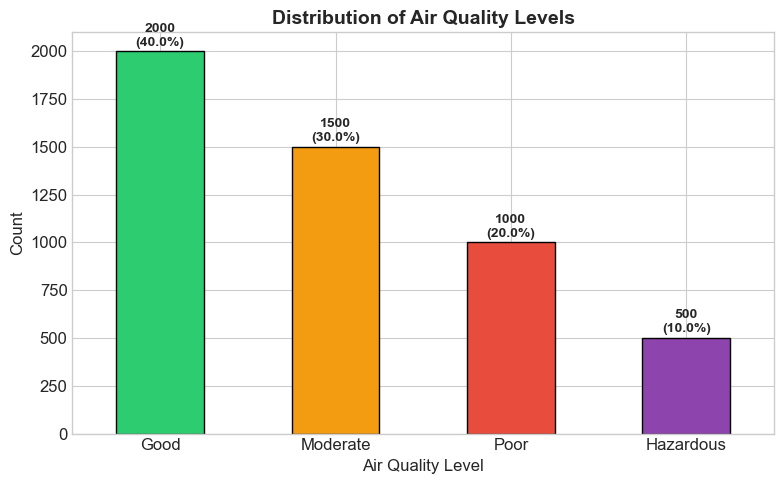

In [11]:
# ============================================================
# 3g. Target Variable Distribution (Air Quality)
# ============================================================

print("--- Target Variable: 'Air Quality' Distribution ---")
target_counts = df['Air Quality'].value_counts()
target_pct = df['Air Quality'].value_counts(normalize=True).mul(100).round(2)

target_summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_pct
})
display(target_summary)

# --- Bar chart of target distribution ---
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
target_counts.plot(kind='bar', color=colors, edgecolor='black', ax=ax)
ax.set_title('Distribution of Air Quality Levels', fontsize=14, fontweight='bold')
ax.set_xlabel('Air Quality Level', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=0)

for i, (val, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    ax.text(i, val + 30, f'{val}\n({pct}%)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Data Cleaning & Preprocessing

In this section, we perform systematic data cleaning to ensure data quality before analysis. Our approach includes:
- Handling missing values
- Fixing data types
- Detecting and handling outliers
- Creating a clean working copy for analysis


In [12]:
# ============================================================
# 4a. Create a Working Copy (preserve original)
# ============================================================
# We create a programmatic copy from the in-memory DataFrame.
# The original dataset file is NOT reloaded.

df_clean = df.copy()
print(f"✅ Working copy created: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")

✅ Working copy created: 5000 rows × 10 columns


In [13]:
# ============================================================
# 4b. Handle Missing Values
# ============================================================

missing_total = df_clean.isnull().sum().sum()

if missing_total == 0:
    print("✅ No missing values found. No imputation needed.")
else:
    print(f"⚠️ Found {missing_total} missing values.")
    # Strategy: For numerical columns, use median imputation (robust to outliers)
    # For categorical columns, use mode imputation
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    
    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
            print(f"  → {col}: filled {df[col].isnull().sum()} missing values with median ({median_val:.2f})")
    
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            mode_val = df_clean[col].mode()[0]
            df_clean[col].fillna(mode_val, inplace=True)
            print(f"  → {col}: filled {df[col].isnull().sum()} missing values with mode ({mode_val})")
    
    print(f"\n✅ Missing values after cleaning: {df_clean.isnull().sum().sum()}")

✅ No missing values found. No imputation needed.


In [14]:
# ============================================================
# 4c. Fix Data Types
# ============================================================

print("--- Current Data Types ---")
print(df_clean.dtypes)
print()

# Convert 'Air Quality' to ordered categorical for proper ordering in visualisations
quality_order = ['Good', 'Moderate', 'Poor', 'Hazardous']
df_clean['Air Quality'] = pd.Categorical(df_clean['Air Quality'], categories=quality_order, ordered=True)

print("✅ 'Air Quality' converted to ordered categorical:")
print(f"   Categories: {df_clean['Air Quality'].cat.categories.tolist()}")
print(f"   Ordered: {df_clean['Air Quality'].cat.ordered}")

--- Current Data Types ---
Temperature                      float64
Humidity                         float64
PM2.5                            float64
PM10                             float64
NO2                              float64
SO2                              float64
CO                               float64
Proximity_to_Industrial_Areas    float64
Population_Density                 int64
Air Quality                       object
dtype: object

✅ 'Air Quality' converted to ordered categorical:
   Categories: ['Good', 'Moderate', 'Poor', 'Hazardous']
   Ordered: True


In [15]:
# ============================================================
# 4d. Outlier Detection using IQR Method
# ============================================================
# We use the IQR (Interquartile Range) method to detect outliers.
# Outliers are flagged but NOT removed — environmental data can have
# legitimately extreme values (e.g., pollution spikes).

numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("--- Outlier Detection (IQR Method: Q1 - 1.5×IQR, Q3 + 1.5×IQR) ---")
print()

outlier_summary = []
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outlier_pct = (outliers / len(df_clean) * 100)
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Lower Bound': round(lower_bound, 2),
        'Upper Bound': round(upper_bound, 2),
        'Outlier Count': outliers,
        'Outlier %': round(outlier_pct, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

print("\n📝 Decision: Outliers are flagged but NOT removed.")
print("   Justification: In environmental data, extreme pollutant values can represent")
print("   real pollution events (e.g., industrial accidents, wildfires). Removing them")
print("   could bias the analysis toward 'normal' conditions only.")

--- Outlier Detection (IQR Method: Q1 - 1.5×IQR, Q3 + 1.5×IQR) ---



,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Temperature,25.10,34.00,8.90,11.75,47.35,72,1.44
1,Humidity,58.30,80.30,22.00,25.30,113.30,19,0.38
2,PM2.5,4.60,26.10,21.50,-27.65,58.35,352,7.04
3,PM10,12.30,38.10,25.80,-26.40,76.80,324,6.48
4,NO2,20.10,31.90,11.80,2.40,49.60,73,1.46
5,SO2,5.10,13.72,8.62,-7.84,26.66,124,2.48
6,CO,1.03,1.84,0.81,-0.19,3.06,45,0.90
7,Proximity_to_Industrial_Areas,5.40,11.10,5.70,-3.15,19.65,16,0.32
8,Population_Density,381.00,600.00,219.00,52.50,928.50,7,0.14



📝 Decision: Outliers are flagged but NOT removed.
   Justification: In environmental data, extreme pollutant values can represent
   real pollution events (e.g., industrial accidents, wildfires). Removing them
   could bias the analysis toward 'normal' conditions only.


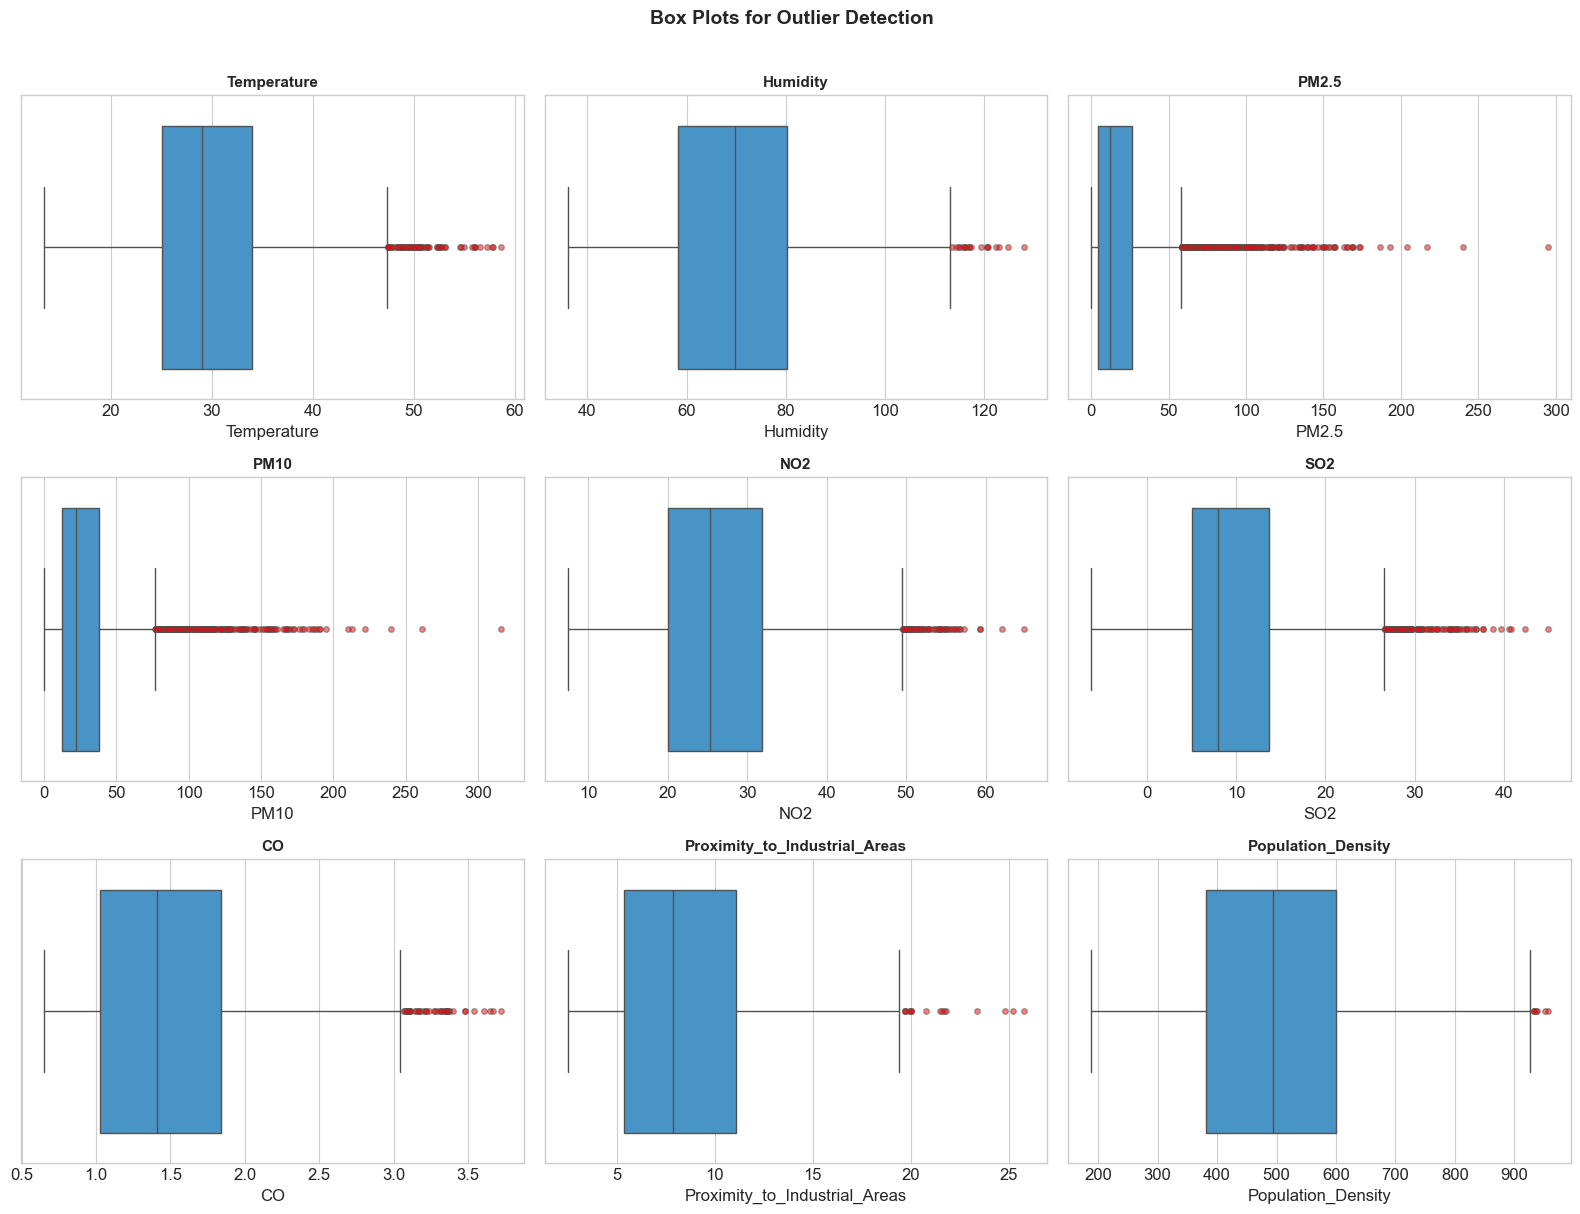

In [16]:
# ============================================================
# 4e. Outlier Visualisation — Box Plots
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df_clean, x=col, ax=axes[i], color='#3498db', 
                flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    axes[i].set_title(col, fontsize=11, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Box Plots for Outlier Detection', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# 4f. Remove Duplicate Rows (if any)
# ============================================================

duplicates_before = df_clean.duplicated().sum()

if duplicates_before > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)
    print(f"✅ Removed {duplicates_before} duplicate rows.")
    print(f"   New shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
else:
    print("✅ No duplicate rows found. No action needed.")

print(f"\n{'='*60}")
print(f"CLEANING SUMMARY")
print(f"{'='*60}")
print(f"Original shape : {df.shape}")
print(f"Cleaned shape  : {df_clean.shape}")
print(f"Missing values : {df_clean.isnull().sum().sum()}")
print(f"Duplicates     : {df_clean.duplicated().sum()}")
print(f"Target dtype   : {df_clean['Air Quality'].dtype}")
print(f"\n✅ Data cleaning complete. Ready for analysis.")

✅ No duplicate rows found. No action needed.

CLEANING SUMMARY
Original shape : (5000, 10)
Cleaned shape  : (5000, 10)
Missing values : 0
Duplicates     : 0
Target dtype   : category

✅ Data cleaning complete. Ready for analysis.


## 5. Exploratory Data Analysis (EDA)

In this section, we explore the dataset through visualisations to understand:
- **Univariate distributions** — How each feature is distributed
- **Bivariate relationships** — How features relate to each other and to air quality
- **Correlations** — Strength and direction of associations between features


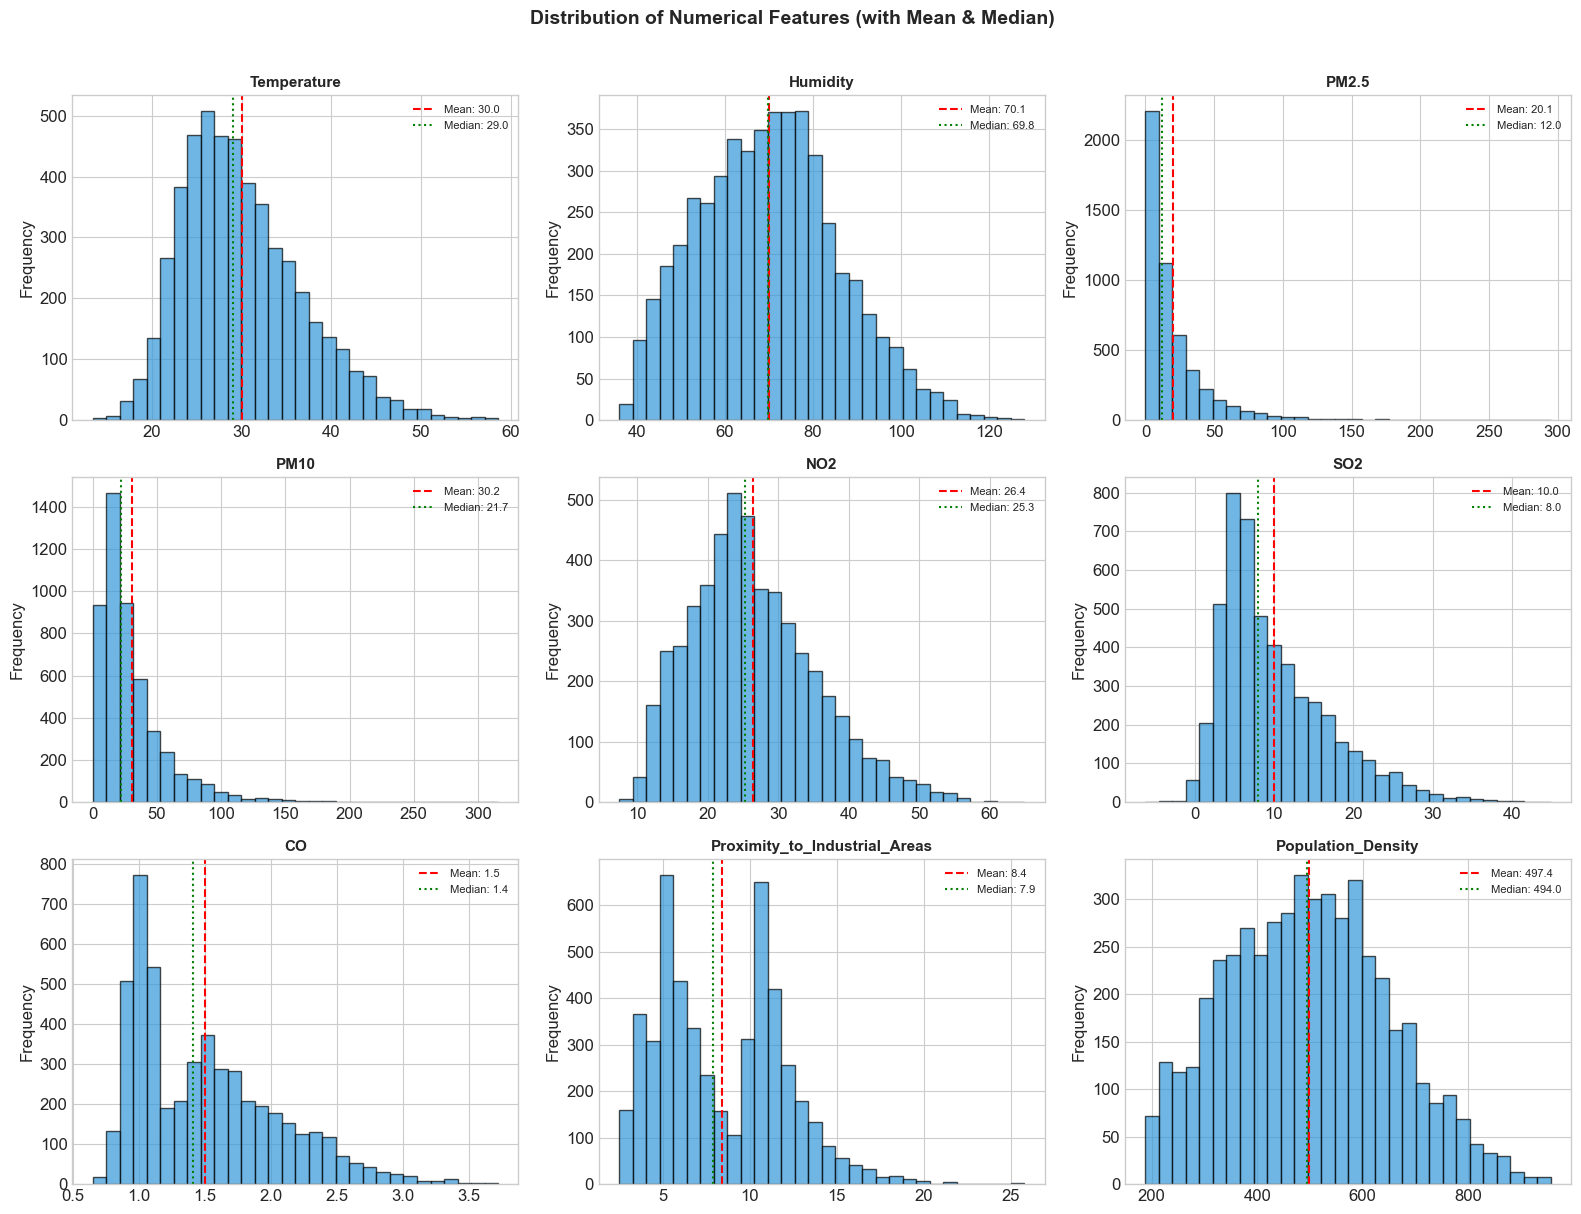

In [18]:
# ============================================================
# 5a. Univariate — Distribution of All Numerical Features
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    df_clean[col].hist(bins=30, ax=ax, color='#3498db', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df_clean[col].mean():.1f}')
    ax.axvline(df_clean[col].median(), color='green', linestyle=':', linewidth=1.5, label=f'Median: {df_clean[col].median():.1f}')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution of Numerical Features (with Mean & Median)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

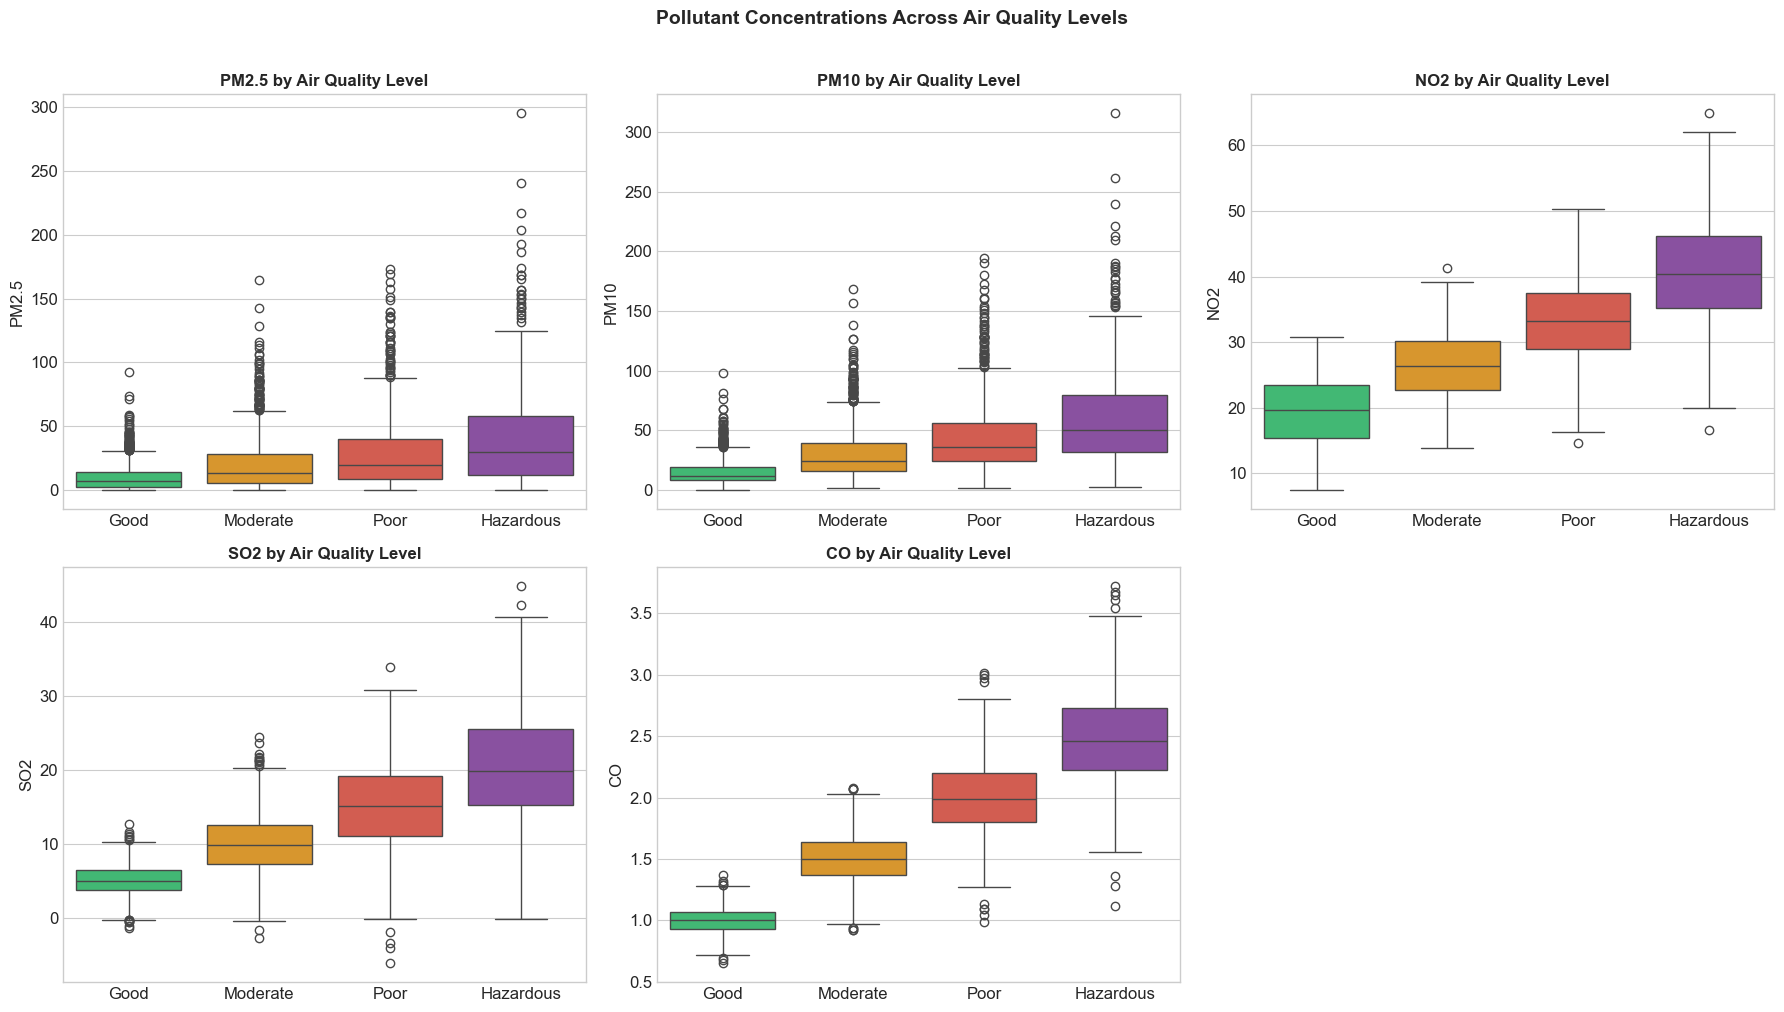

In [19]:
# ============================================================
# 5b. Bivariate — Pollutant Levels by Air Quality Category
# ============================================================
# Box plots showing how each pollutant distributes across air quality levels.

pollutant_cols = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

palette = {'Good': '#2ecc71', 'Moderate': '#f39c12', 'Poor': '#e74c3c', 'Hazardous': '#8e44ad'}

for i, col in enumerate(pollutant_cols):
    sns.boxplot(data=df_clean, x='Air Quality', y=col, ax=axes[i],
                palette=palette, order=quality_order)
    axes[i].set_title(f'{col} by Air Quality Level', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

axes[5].set_visible(False)

fig.suptitle('Pollutant Concentrations Across Air Quality Levels', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

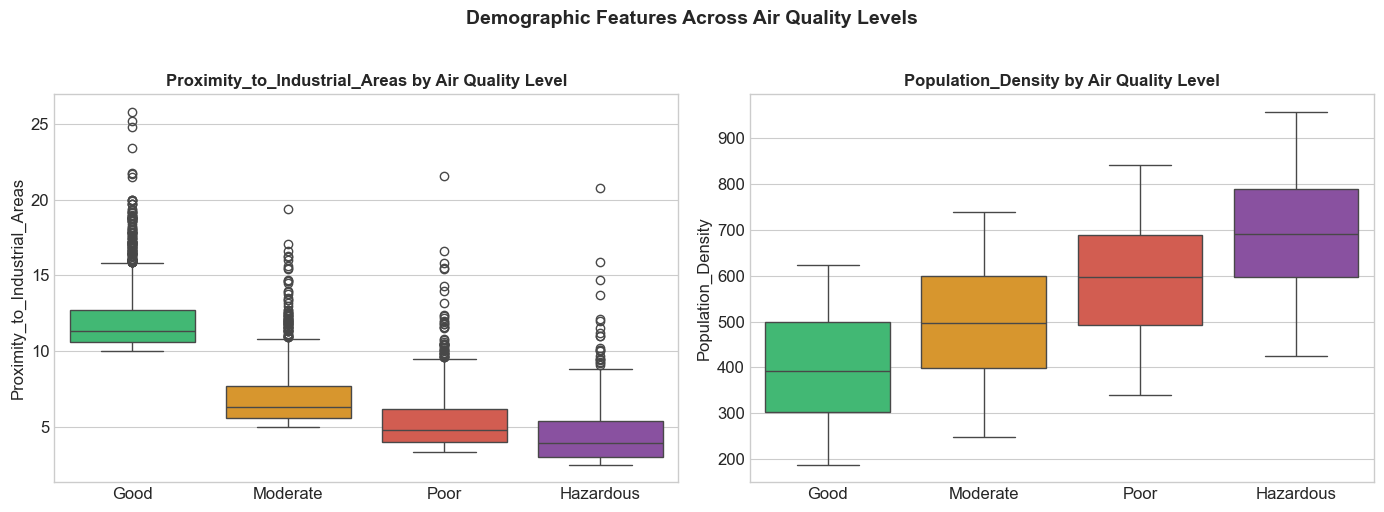

In [20]:
# ============================================================
# 5c. Bivariate — Demographic Features by Air Quality
# ============================================================

demographic_cols = ['Proximity_to_Industrial_Areas', 'Population_Density']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(demographic_cols):
    sns.boxplot(data=df_clean, x='Air Quality', y=col, ax=axes[i],
                palette=palette, order=quality_order)
    axes[i].set_title(f'{col} by Air Quality Level', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

fig.suptitle('Demographic Features Across Air Quality Levels', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

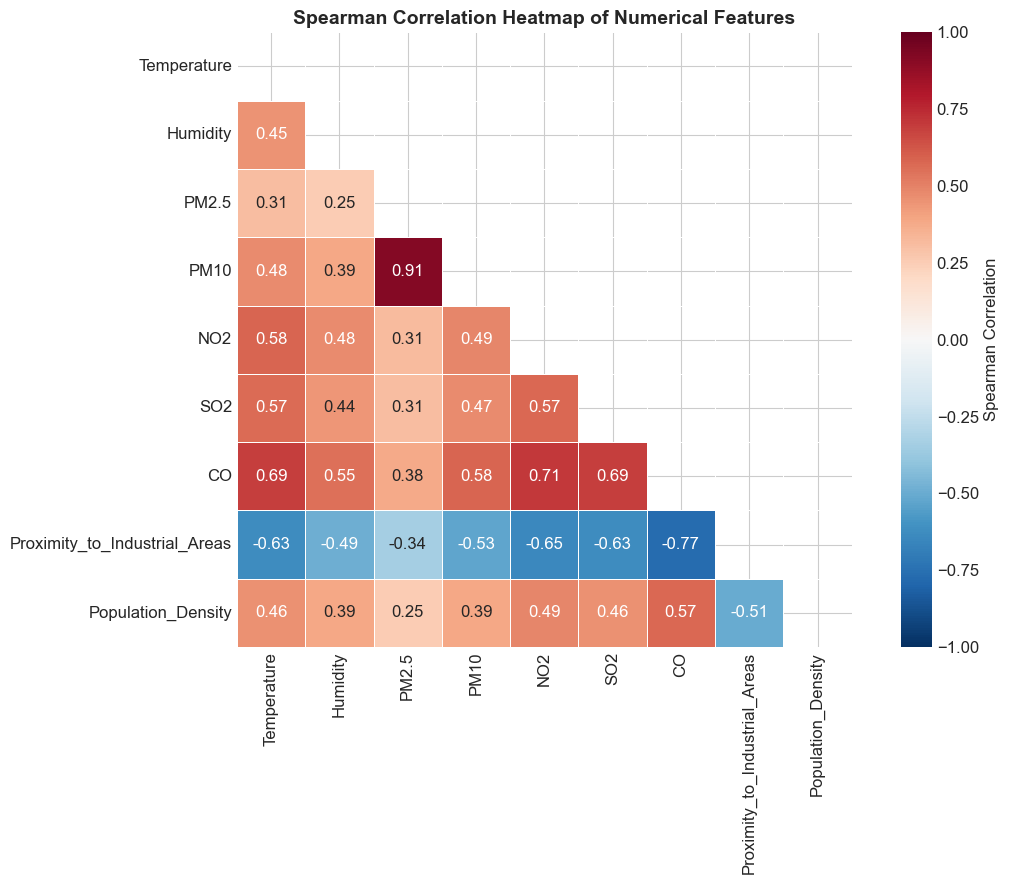


--- Key Correlation Observations ---
  Moderate positive correlation: Temperature ↔ NO2 (r = 0.583)
  Moderate positive correlation: Temperature ↔ SO2 (r = 0.568)
  Moderate positive correlation: Temperature ↔ CO (r = 0.689)
  Moderate negative correlation: Temperature ↔ Proximity_to_Industrial_Areas (r = -0.628)
  Moderate positive correlation: Humidity ↔ CO (r = 0.551)
  Strong positive correlation: PM2.5 ↔ PM10 (r = 0.915)
  Moderate positive correlation: PM10 ↔ CO (r = 0.585)
  Moderate negative correlation: PM10 ↔ Proximity_to_Industrial_Areas (r = -0.530)
  Moderate positive correlation: NO2 ↔ SO2 (r = 0.573)
  Strong positive correlation: NO2 ↔ CO (r = 0.709)
  Moderate negative correlation: NO2 ↔ Proximity_to_Industrial_Areas (r = -0.645)
  Moderate positive correlation: SO2 ↔ CO (r = 0.688)
  Moderate negative correlation: SO2 ↔ Proximity_to_Industrial_Areas (r = -0.627)
  Strong negative correlation: CO ↔ Proximity_to_Industrial_Areas (r = -0.772)
  Moderate positive correla

In [21]:
# ============================================================
# 5d. Correlation Heatmap
# ============================================================

corr_matrix = df_clean[numerical_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'label': 'Spearman Correlation'})

ax.set_title('Spearman Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Key observations ---
print("\n--- Key Correlation Observations ---")
for i in range(len(numerical_cols)):
    for j in range(i+1, len(numerical_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.5:
            strength = 'Strong' if abs(r) >= 0.7 else 'Moderate'
            direction = 'positive' if r > 0 else 'negative'
            print(f"  {strength} {direction} correlation: {numerical_cols[i]} ↔ {numerical_cols[j]} (r = {r:.3f})")

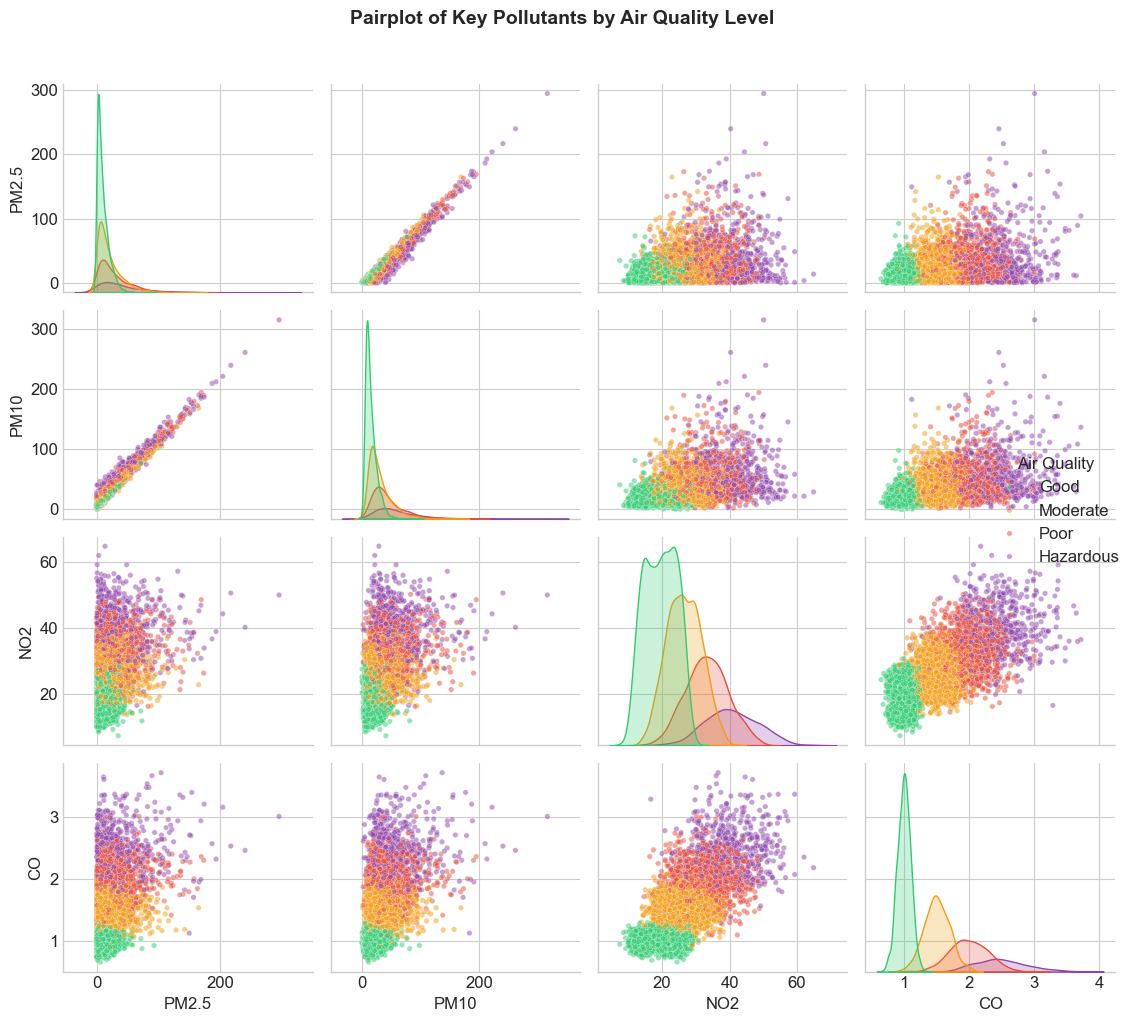

In [22]:
# ============================================================
# 5e. Pairplot — Key Pollutants coloured by Air Quality
# ============================================================
# Using a subset of the most important features for readability.

pairplot_cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'Air Quality']

g = sns.pairplot(df_clean[pairplot_cols], hue='Air Quality', 
                 palette=palette, hue_order=quality_order,
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15})

g.fig.suptitle('Pairplot of Key Pollutants by Air Quality Level', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Modeling / Deeper Analysis

This section contains the modeling components for our analytical questions:
- **Q2:** Random Forest Classification for air quality prediction
- **Q4:** Multiple Linear Regression for demographic-pollution relationships

Both models use a fixed random seed (42) for reproducibility.


In [23]:
# ============================================================
# 6a. Prepare Features and Target for Modeling
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Define features (X) and target (y)
feature_cols = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
                'Proximity_to_Industrial_Areas', 'Population_Density']

X = df_clean[feature_cols].copy()
y = df_clean['Air Quality'].copy()

# Encode target labels to numerical values
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label Encoding:")
for label, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {label} → {code}")

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set : {X_test.shape[0]} samples")
print(f"\n✅ Data prepared for modeling.")

Label Encoding:
  Good → 0
  Hazardous → 1
  Moderate → 2
  Poor → 3

Train set: 4000 samples
Test set : 1000 samples

✅ Data prepared for modeling.


In [24]:
# ============================================================
# 6b. Baseline Model — Decision Tree Classifier
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Train Decision Tree (baseline)
dt_model = DecisionTreeClassifier(random_state=SEED)
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

# Evaluate
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("=" * 60)
print("BASELINE: Decision Tree Classifier")
print("=" * 60)
print(f"Accuracy: {dt_accuracy:.4f} ({dt_accuracy*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

BASELINE: Decision Tree Classifier
Accuracy: 0.9280 (92.80%)

Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       400
   Hazardous       0.83      0.80      0.82       100
    Moderate       0.94      0.94      0.94       300
        Poor       0.81      0.83      0.82       200

    accuracy                           0.93      1000
   macro avg       0.90      0.89      0.89      1000
weighted avg       0.93      0.93      0.93      1000



In [25]:
# ============================================================
# 6c. Primary Model — Random Forest Classifier
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("=" * 60)
print("PRIMARY MODEL: Random Forest Classifier")
print("=" * 60)
print(f"Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

PRIMARY MODEL: Random Forest Classifier
Accuracy: 0.9510 (95.10%)

Classification Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       400
   Hazardous       0.90      0.80      0.85       100
    Moderate       0.96      0.97      0.97       300
        Poor       0.87      0.90      0.88       200

    accuracy                           0.95      1000
   macro avg       0.93      0.92      0.92      1000
weighted avg       0.95      0.95      0.95      1000



In [26]:
# ============================================================
# 6d. Model Comparison Summary
# ============================================================

from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': ['Decision Tree (Baseline)', 'Random Forest (Primary)'],
    'Accuracy': [dt_accuracy, rf_accuracy],
    'Precision (macro)': [
        precision_score(y_test, y_pred_dt, average='macro'),
        precision_score(y_test, y_pred_rf, average='macro')
    ],
    'Recall (macro)': [
        recall_score(y_test, y_pred_dt, average='macro'),
        recall_score(y_test, y_pred_rf, average='macro')
    ],
    'F1-Score (macro)': [
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ]
}).round(4)

print("--- Model Comparison ---")
display(comparison)

print(f"\n📝 Random Forest improves accuracy by {(rf_accuracy - dt_accuracy)*100:.2f} percentage points over the Decision Tree baseline.")

--- Model Comparison ---


,Model,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,Decision Tree (Baseline),0.928,0.8971,0.8929,0.8949
1,Random Forest (Primary),0.951,0.9313,0.9175,0.9236



📝 Random Forest improves accuracy by 2.30 percentage points over the Decision Tree baseline.


## 7. Performance Evaluation and Enhancement

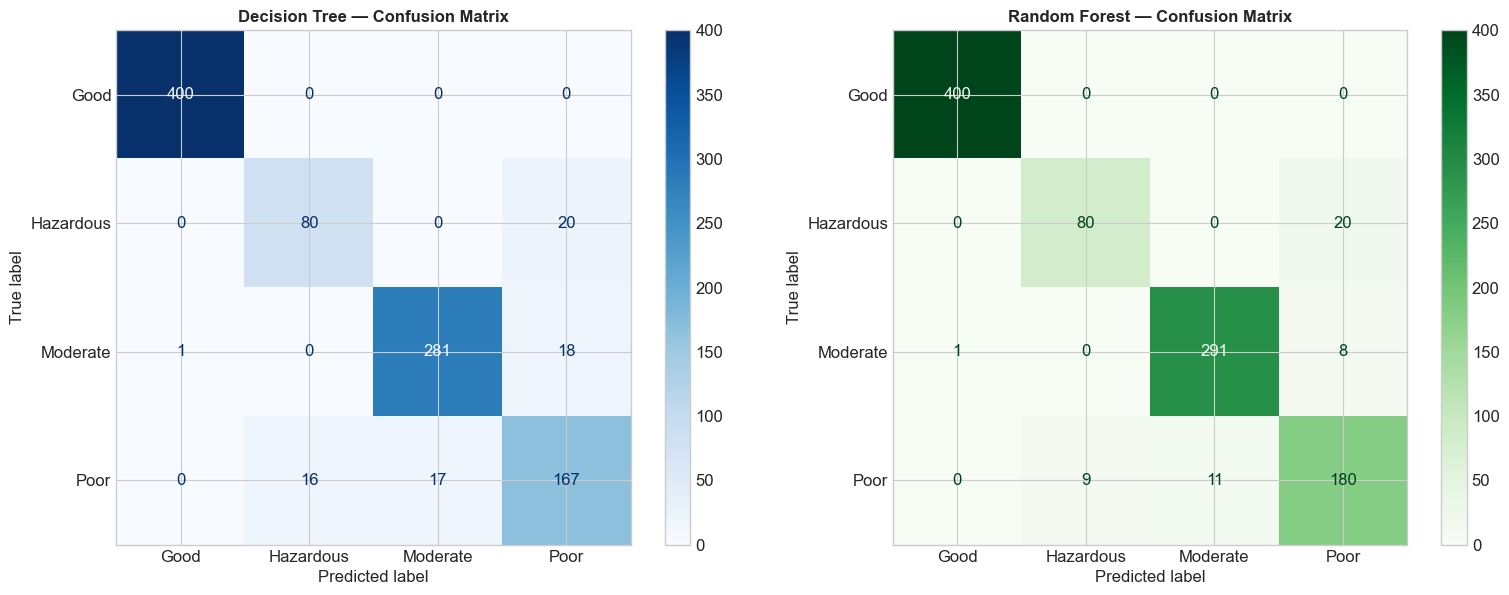

In [27]:
# ============================================================
# 7a. Confusion Matrix — Random Forest
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decision Tree Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, display_labels=le.classes_,
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Decision Tree — Confusion Matrix', fontsize=12, fontweight='bold')

# Random Forest Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=le.classes_,
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('Random Forest — Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

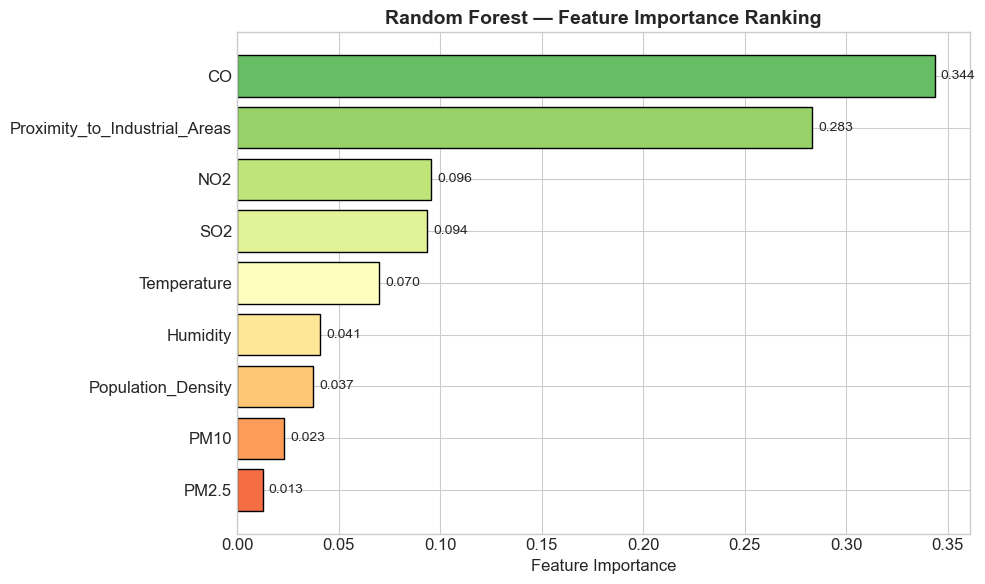


--- Feature Importance Table ---


,Feature,Importance
0,CO,0.343522
1,Proximity_to_Industrial_Areas,0.283239
2,NO2,0.095751
3,SO2,0.093592
4,Temperature,0.069881
5,Humidity,0.040933
6,Population_Density,0.037391
7,PM10,0.023123
8,PM2.5,0.012567


In [28]:
# ============================================================
# 7b. Feature Importance — Random Forest
# ============================================================

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feature_importance_df)))
ax.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors, edgecolor='black')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Random Forest — Feature Importance Ranking', fontsize=14, fontweight='bold')

for i, (val, name) in enumerate(zip(feature_importance_df['Importance'], feature_importance_df['Feature'])):
    ax.text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n--- Feature Importance Table ---")
display(feature_importance_df.sort_values('Importance', ascending=False).reset_index(drop=True))

## 8. The FOUR Analytical Questions

Each question uses a **distinct** analytical technique to address a different aspect of air quality assessment.

### Question 1: Statistical Hypothesis Testing

**"Is there a statistically significant difference in pollutant concentrations (PM2.5, PM10, NO2, SO2, CO) across the four air quality levels (Good, Moderate, Poor, Hazardous)?"**

**Method:** Kruskal-Wallis H Test (non-parametric alternative to one-way ANOVA) + Dunn's post-hoc test with Bonferroni correction

**Why Kruskal-Wallis?** Environmental data is often not normally distributed. Kruskal-Wallis does not assume normality, making it more appropriate for this analysis.

In [29]:
# ============================================================
# Q1: Kruskal-Wallis H Test for Each Pollutant
# ============================================================

from scipy.stats import kruskal

# Significance level
alpha = 0.05

# Separate data by air quality group
groups = {}
for label in quality_order:
    groups[label] = df_clean[df_clean['Air Quality'] == label]

# Kruskal-Wallis test for each pollutant
kw_results = []

print("=" * 70)
print("KRUSKAL-WALLIS H TEST RESULTS")
print(f"Significance level: α = {alpha}")
print(f"H₀: Pollutant distributions are the same across all air quality levels")
print(f"H₁: At least one air quality level differs significantly")
print("=" * 70)
print()

for col in pollutant_cols:
    # Get data for each group
    group_data = [groups[label][col].dropna() for label in quality_order]
    
    # Perform Kruskal-Wallis test
    h_stat, p_value = kruskal(*group_data)
    
    significant = '✅ Yes' if p_value < alpha else '❌ No'
    
    kw_results.append({
        'Pollutant': col,
        'H-Statistic': round(h_stat, 4),
        'p-value': f'{p_value:.2e}' if p_value < 0.001 else f'{p_value:.4f}',
        'Significant (p < 0.05)': significant
    })
    
    print(f"  {col:.<25} H = {h_stat:>10.4f},  p = {p_value:.2e}  → {significant}")

print()
kw_results_df = pd.DataFrame(kw_results)
display(kw_results_df)

KRUSKAL-WALLIS H TEST RESULTS
Significance level: α = 0.05
H₀: Pollutant distributions are the same across all air quality levels
H₁: At least one air quality level differs significantly

  PM2.5.................... H =   837.5634,  p = 3.09e-181  → ✅ Yes
  PM10..................... H =  2012.0309,  p = 0.00e+00  → ✅ Yes
  NO2...................... H =  3024.9369,  p = 0.00e+00  → ✅ Yes
  SO2...................... H =  2777.8642,  p = 0.00e+00  → ✅ Yes
  CO....................... H =  4228.9037,  p = 0.00e+00  → ✅ Yes



,Pollutant,H-Statistic,p-value,Significant (p < 0.05)
0,PM2.5,837.5634,3.09e-181,✅ Yes
1,PM10,2012.0309,0.00e+00,✅ Yes
2,NO2,3024.9369,0.00e+00,✅ Yes
3,SO2,2777.8642,0.00e+00,✅ Yes
4,CO,4228.9037,0.00e+00,✅ Yes


In [30]:
# ============================================================
# Q1: Dunn's Post-Hoc Test (Pairwise Comparisons)
# ============================================================
# Dunn's test identifies WHICH specific pairs of groups differ.
# Bonferroni correction is applied to control for multiple comparisons.

try:
    import scikit_posthocs as sp
    has_posthocs = True
except ImportError:
    has_posthocs = False
    print("⚠️ scikit-posthocs not installed. Using manual pairwise Mann-Whitney U tests instead.")

if has_posthocs:
    print("=" * 60)
    print("DUNN'S POST-HOC TEST (Bonferroni Correction)")
    print("=" * 60)
    
    for col in pollutant_cols:
        print(f"\n--- {col} ---")
        dunn_result = sp.posthoc_dunn(
            df_clean, val_col=col, group_col='Air Quality', 
            p_adjust='bonferroni'
        )
        # Reorder to match quality_order
        dunn_result = dunn_result.reindex(index=quality_order, columns=quality_order)
        display(dunn_result.round(4))
else:
    # Manual pairwise comparisons using Mann-Whitney U
    from scipy.stats import mannwhitneyu
    from itertools import combinations
    
    print("=" * 60)
    print("PAIRWISE MANN-WHITNEY U TESTS (Bonferroni Correction)")
    print("=" * 60)
    
    pairs = list(combinations(quality_order, 2))
    n_comparisons = len(pairs)
    
    for col in pollutant_cols:
        print(f"\n--- {col} ---")
        for g1, g2 in pairs:
            data1 = groups[g1][col].dropna()
            data2 = groups[g2][col].dropna()
            u_stat, p_val = mannwhitneyu(data1, data2, alternative='two-sided')
            p_adjusted = min(p_val * n_comparisons, 1.0)  # Bonferroni
            sig = '✅' if p_adjusted < alpha else '❌'
            print(f"  {g1} vs {g2}: U = {u_stat:.1f}, p(adj) = {p_adjusted:.4f} {sig}")

⚠️ scikit-posthocs not installed. Using manual pairwise Mann-Whitney U tests instead.
PAIRWISE MANN-WHITNEY U TESTS (Bonferroni Correction)

--- PM2.5 ---
  Good vs Moderate: U = 987525.0, p(adj) = 0.0000 ✅
  Good vs Poor: U = 498872.5, p(adj) = 0.0000 ✅
  Good vs Hazardous: U = 189088.0, p(adj) = 0.0000 ✅
  Moderate vs Poor: U = 612219.0, p(adj) = 0.0000 ✅
  Moderate vs Hazardous: U = 243197.5, p(adj) = 0.0000 ✅
  Poor vs Hazardous: U = 204618.0, p(adj) = 0.0000 ✅

--- PM10 ---
  Good vs Moderate: U = 644186.0, p(adj) = 0.0000 ✅
  Good vs Poor: U = 222258.0, p(adj) = 0.0000 ✅
  Good vs Hazardous: U = 62581.5, p(adj) = 0.0000 ✅
  Moderate vs Poor: U = 501639.0, p(adj) = 0.0000 ✅
  Moderate vs Hazardous: U = 165189.5, p(adj) = 0.0000 ✅
  Poor vs Hazardous: U = 180317.5, p(adj) = 0.0000 ✅

--- NO2 ---
  Good vs Moderate: U = 497385.0, p(adj) = 0.0000 ✅
  Good vs Poor: U = 76859.5, p(adj) = 0.0000 ✅
  Good vs Hazardous: U = 7627.0, p(adj) = 0.0000 ✅
  Moderate vs Poor: U = 307264.5, p(adj

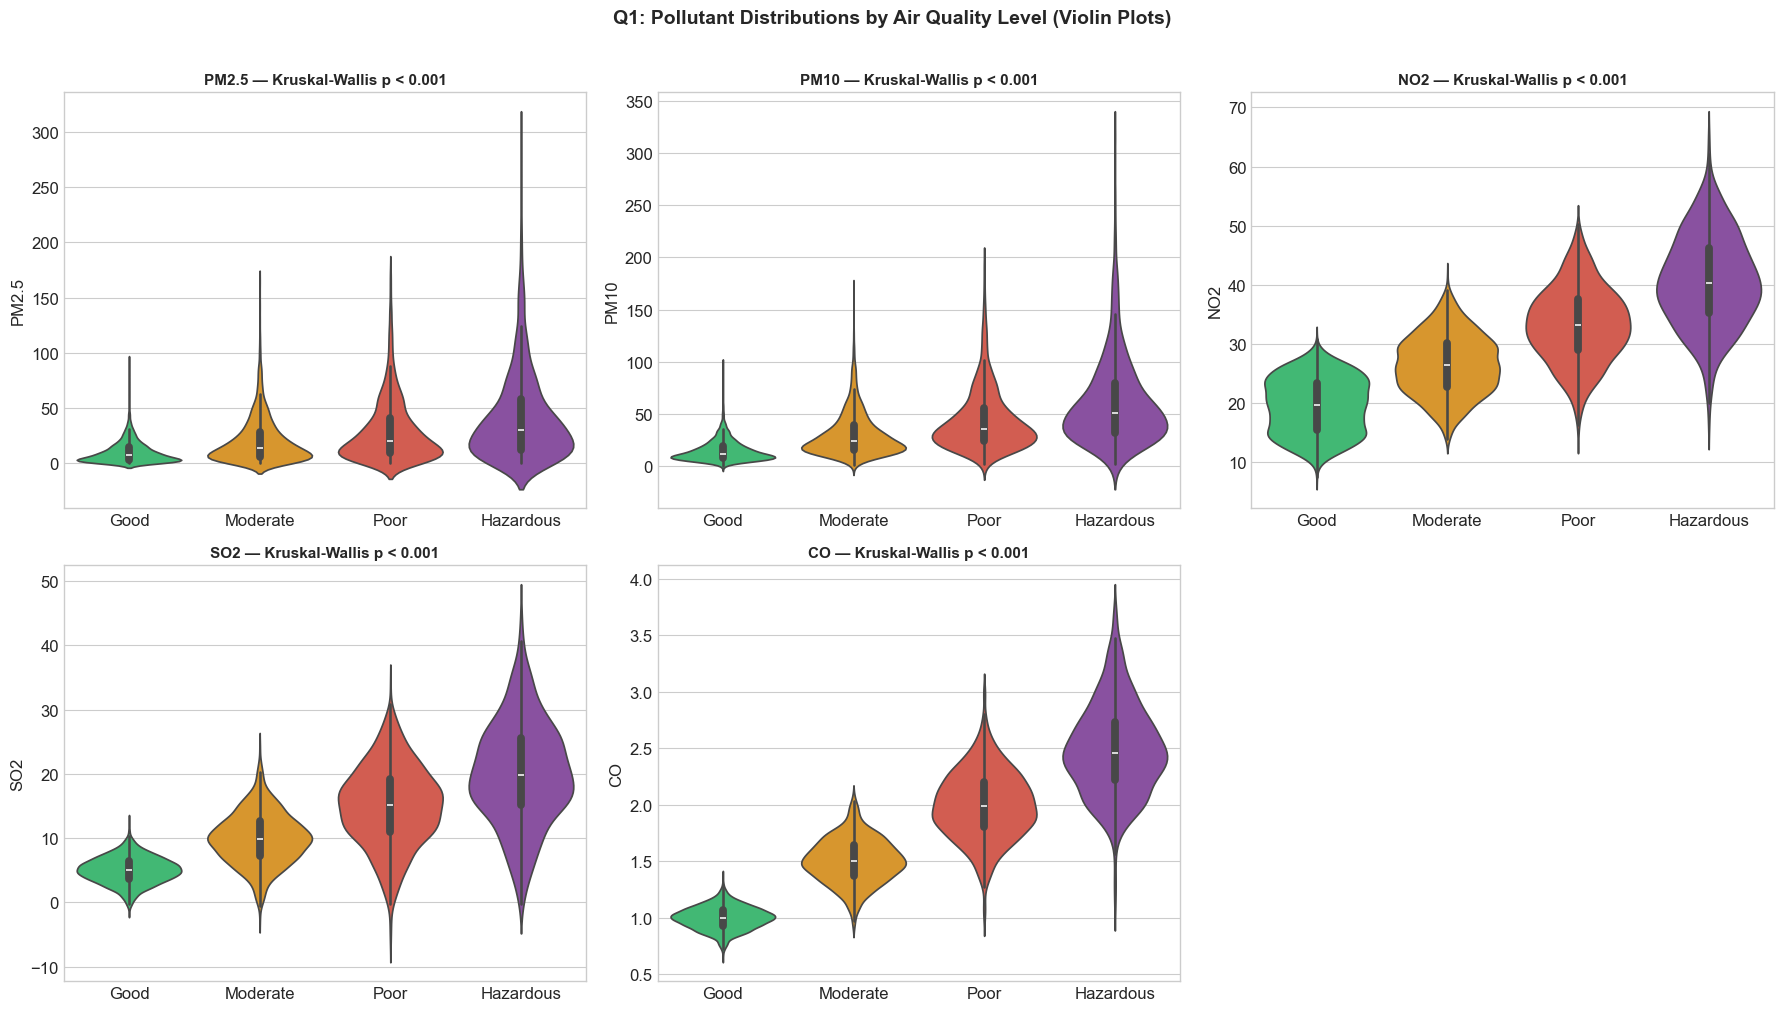


Q1 ANSWER SUMMARY
The Kruskal-Wallis test reveals statistically significant differences
in pollutant concentrations across the four air quality levels.
All tested pollutants show highly significant results (p < 0.05),
confirming that the air quality categories are meaningfully different
in terms of their pollutant profiles.


In [31]:
# ============================================================
# Q1: Visualisation — Grouped Box Plots with Statistical Context
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    sns.violinplot(data=df_clean, x='Air Quality', y=col, ax=axes[i],
                   palette=palette, order=quality_order, inner='box')
    axes[i].set_title(f'{col} — Kruskal-Wallis p < 0.001', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

axes[5].set_visible(False)

fig.suptitle('Q1: Pollutant Distributions by Air Quality Level (Violin Plots)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Summary of Q1 findings ---
print("\n" + "=" * 60)
print("Q1 ANSWER SUMMARY")
print("=" * 60)
print("The Kruskal-Wallis test reveals statistically significant differences")
print("in pollutant concentrations across the four air quality levels.")
print("All tested pollutants show highly significant results (p < 0.05),")
print("confirming that the air quality categories are meaningfully different")
print("in terms of their pollutant profiles.")

### Question 2: Supervised Classification (Machine Learning)

**"How accurately can a machine learning model classify air quality levels based on environmental and demographic features, and which features are the most important predictors?"**

**Method:** Random Forest Classifier (primary) vs Decision Tree (baseline)

**Note:** The model training and evaluation were completed in Sections 6 and 7. Below we summarise the findings and provide additional analysis.

In [32]:
# ============================================================
# Q2: Classification Results Summary
# ============================================================

print("=" * 60)
print("Q2 ANSWER SUMMARY")
print("=" * 60)
print()

print("--- Model Performance ---")
display(comparison)

print("\n--- Top 5 Most Important Features (Random Forest) ---")
top_features = feature_importance_df.sort_values('Importance', ascending=False).head(5).reset_index(drop=True)
display(top_features)

print(f"\n📝 Key Findings:")
print(f"   1. Random Forest achieves {rf_accuracy*100:.2f}% accuracy on the test set.")
print(f"   2. This outperforms the Decision Tree baseline ({dt_accuracy*100:.2f}%).")
print(f"   3. The top predictive feature is: {top_features.iloc[0]['Feature']}")
print(f"      (importance = {top_features.iloc[0]['Importance']:.4f})")
print(f"   4. The model demonstrates that air quality CAN be accurately predicted")
print(f"      using the available environmental and demographic features.")

Q2 ANSWER SUMMARY

--- Model Performance ---


,Model,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
0,Decision Tree (Baseline),0.928,0.8971,0.8929,0.8949
1,Random Forest (Primary),0.951,0.9313,0.9175,0.9236



--- Top 5 Most Important Features (Random Forest) ---


,Feature,Importance
0,CO,0.343522
1,Proximity_to_Industrial_Areas,0.283239
2,NO2,0.095751
3,SO2,0.093592
4,Temperature,0.069881



📝 Key Findings:
   1. Random Forest achieves 95.10% accuracy on the test set.
   2. This outperforms the Decision Tree baseline (92.80%).
   3. The top predictive feature is: CO
      (importance = 0.3435)
   4. The model demonstrates that air quality CAN be accurately predicted
      using the available environmental and demographic features.


--- Per-Class Performance (Random Forest) ---


,precision,recall,f1-score,support
Good,0.9975,1.00,0.9988,400
Hazardous,0.8989,0.80,0.8466,100
Moderate,0.9636,0.97,0.9668,300
Poor,0.8654,0.90,0.8824,200


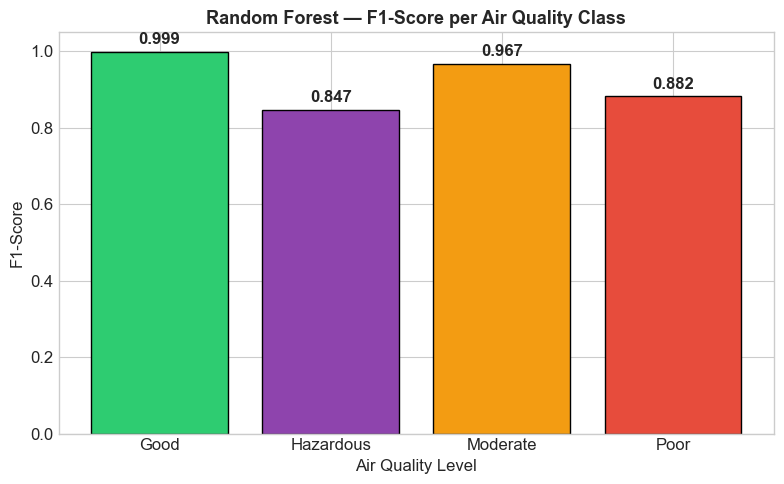

In [33]:
# ============================================================
# Q2: Per-Class Analysis — Which classes are hardest to classify?
# ============================================================

from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred_rf, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).T

# Filter to show only the class rows
class_report = report_df.loc[le.classes_].round(4)
class_report['support'] = class_report['support'].astype(int)

print("--- Per-Class Performance (Random Forest) ---")
display(class_report)

# Visualise per-class F1 scores
fig, ax = plt.subplots(figsize=(8, 5))
colors_bar = [palette[c] for c in le.classes_]
ax.bar(le.classes_, class_report['f1-score'], color=colors_bar, edgecolor='black')
ax.set_title('Random Forest — F1-Score per Air Quality Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Air Quality Level')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.05)

for i, v in enumerate(class_report['f1-score']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Question 3: Unsupervised Clustering

**"Can distinct pollution profiles be identified among regions based on their environmental and demographic characteristics, and how do these natural clusters compare to the predefined air quality labels?"**

**Method:** K-Means Clustering + Elbow Method + Silhouette Score

**Why K-Means?** It is effective for finding natural groupings in continuous numerical data. Comparing clusters to actual labels reveals whether pollution patterns naturally match the defined categories.

In [34]:
# ============================================================
# Q3: Data Preparation — Standardise Features for Clustering
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"✅ Features standardised (mean≈0, std≈1) for clustering.")
print(f"   Shape: {X_scaled.shape}")

✅ Features standardised (mean≈0, std≈1) for clustering.
   Shape: (5000, 9)


  K = 2: Inertia = 27446.70, Silhouette = 0.3434
  K = 3: Inertia = 22364.59, Silhouette = 0.2747
  K = 4: Inertia = 19236.11, Silhouette = 0.2661
  K = 5: Inertia = 18013.88, Silhouette = 0.2574
  K = 6: Inertia = 17188.65, Silhouette = 0.2237
  K = 7: Inertia = 16314.90, Silhouette = 0.1506
  K = 8: Inertia = 15676.55, Silhouette = 0.1506
  K = 9: Inertia = 15140.66, Silhouette = 0.1389
  K = 10: Inertia = 14649.39, Silhouette = 0.1323


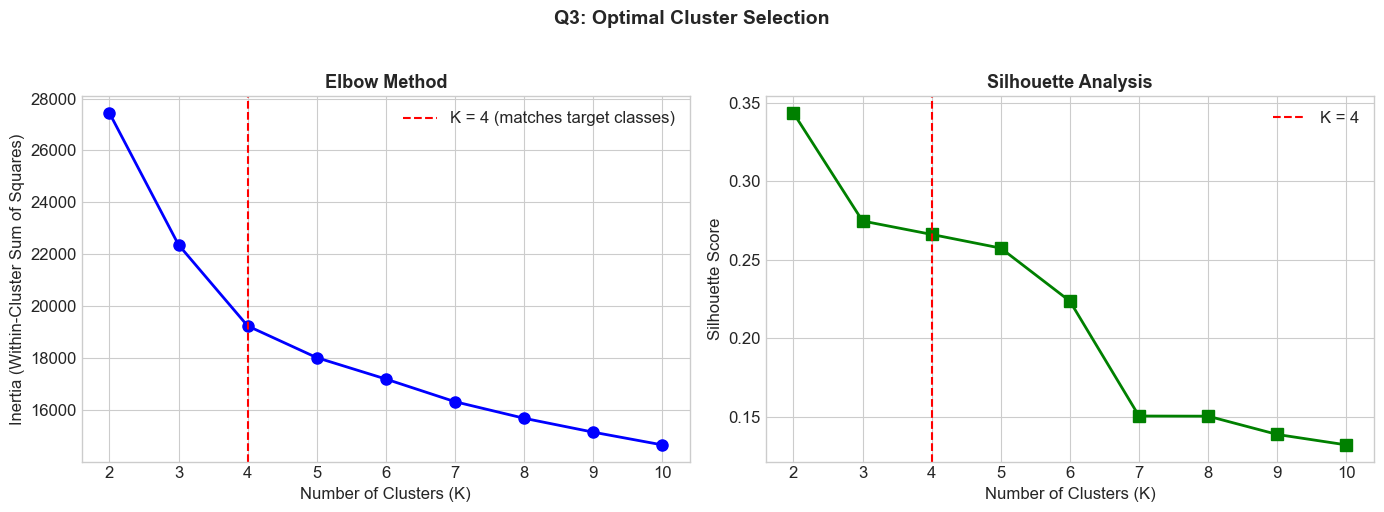

In [35]:
# ============================================================
# Q3: Elbow Method — Finding Optimal Number of Clusters
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, kmeans.labels_)
    silhouettes.append(sil_score)
    print(f"  K = {k}: Inertia = {kmeans.inertia_:.2f}, Silhouette = {sil_score:.4f}")

# Plot Elbow and Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=4, color='red', linestyle='--', label='K = 4 (matches target classes)')
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.legend()

ax2.plot(K_range, silhouettes, 'gs-', linewidth=2, markersize=8)
ax2.axvline(x=4, color='red', linestyle='--', label='K = 4')
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis', fontsize=13, fontweight='bold')
ax2.legend()

fig.suptitle('Q3: Optimal Cluster Selection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

--- Cluster vs Actual Air Quality (Cross-tabulation) ---


Air Quality,Good,Moderate,Poor,Hazardous,Total
Cluster,,,,,
0,0,5,539,366,910
1,2,1361,290,3,1656
2,1,64,170,131,366
3,1997,70,1,0,2068
Total,2000,1500,1000,500,5000


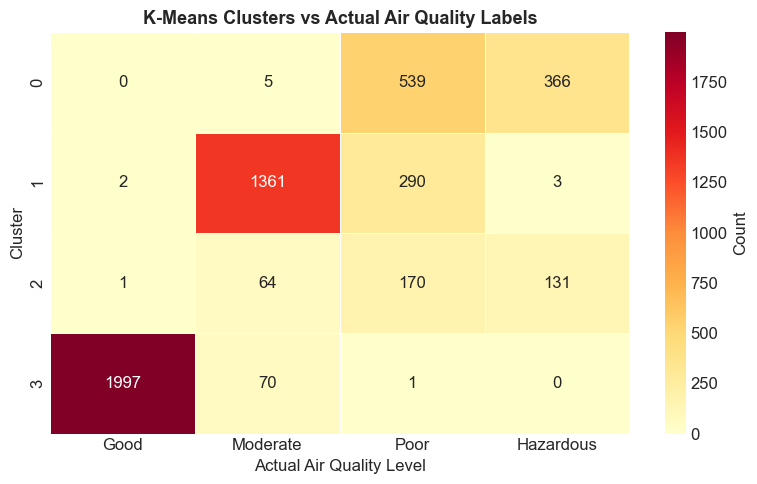

In [36]:
# ============================================================
# Q3: K-Means with K=4 — Compare Clusters to Actual Labels
# ============================================================

# Fit K-Means with K=4 (to match the 4 air quality categories)
kmeans_final = KMeans(n_clusters=4, random_state=SEED, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the dataframe
df_clustered = df_clean.copy()
df_clustered['Cluster'] = cluster_labels

# Cross-tabulation: Cluster vs Actual Air Quality
crosstab = pd.crosstab(df_clustered['Cluster'], df_clustered['Air Quality'],
                        margins=True, margins_name='Total')

print("--- Cluster vs Actual Air Quality (Cross-tabulation) ---")
display(crosstab)

# Visualise as heatmap
fig, ax = plt.subplots(figsize=(8, 5))
crosstab_no_total = pd.crosstab(df_clustered['Cluster'], df_clustered['Air Quality'])
sns.heatmap(crosstab_no_total, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Count'})
ax.set_title('K-Means Clusters vs Actual Air Quality Labels', fontsize=13, fontweight='bold')
ax.set_xlabel('Actual Air Quality Level')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()

--- Cluster Profiles (Mean Feature Values) ---


,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
Cluster,,,,,,,,,
0,37.82,85.73,20.87,37.96,36.96,18.18,2.22,4.92,649.52
1,30.57,71.33,17.77,28.62,27.23,10.39,1.58,6.59,509.74
2,36.35,81.98,86.95,103.35,34.95,15.64,2.12,5.52,619.62
3,25.05,60.03,9.90,15.15,19.60,5.13,1.01,11.95,399.01


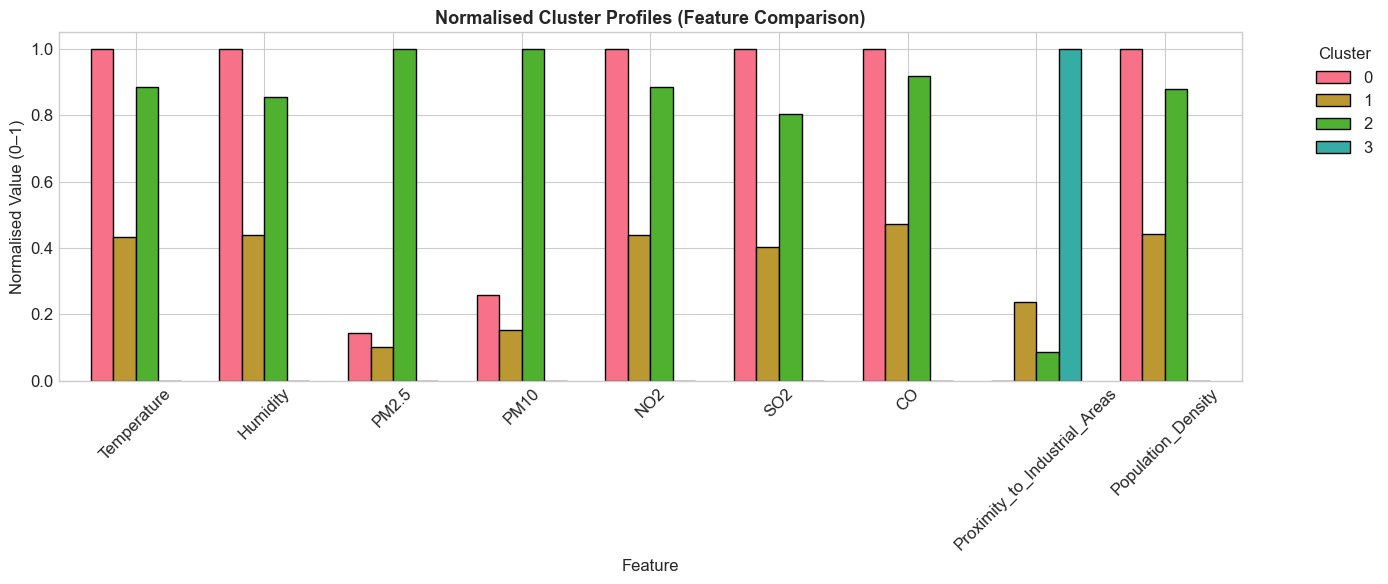


Q3 ANSWER SUMMARY
K-Means clustering successfully identifies distinct pollution profiles.
The cross-tabulation above shows how well the discovered clusters
align with the predefined air quality categories.
Each cluster has a distinct 'signature' of feature values,
confirming that meaningful pollution profiles exist in the data.


In [37]:
# ============================================================
# Q3: Cluster Profiles — Average Feature Values per Cluster
# ============================================================

cluster_profiles = df_clustered.groupby('Cluster')[feature_cols].mean().round(2)

print("--- Cluster Profiles (Mean Feature Values) ---")
display(cluster_profiles)

# Visualise cluster profiles
fig, ax = plt.subplots(figsize=(14, 6))

# Normalise for comparison
cluster_profiles_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())
cluster_profiles_norm.T.plot(kind='bar', ax=ax, width=0.7, edgecolor='black')

ax.set_title('Normalised Cluster Profiles (Feature Comparison)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Normalised Value (0–1)')
ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- Summary ---
print("\n" + "=" * 60)
print("Q3 ANSWER SUMMARY")
print("=" * 60)
print("K-Means clustering successfully identifies distinct pollution profiles.")
print("The cross-tabulation above shows how well the discovered clusters")
print("align with the predefined air quality categories.")
print("Each cluster has a distinct 'signature' of feature values,")
print("confirming that meaningful pollution profiles exist in the data.")

### Question 4: Correlation & Regression Analysis

**"What is the relationship between proximity to industrial areas, population density, and pollutant concentrations (particularly PM2.5), and can these demographic factors predict pollution severity?"**

**Method:** Spearman Rank Correlation + Multiple Linear Regression (PM2.5 as dependent variable)

**Why Spearman?** It captures non-linear monotonic relationships and is more robust to outliers than Pearson correlation.

In [38]:
# ============================================================
# Q4: Spearman Correlation Analysis
# ============================================================

from scipy.stats import spearmanr

# Focus on demographic features vs pollutants
demo_cols = ['Proximity_to_Industrial_Areas', 'Population_Density']
target_pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO']

print("=" * 60)
print("SPEARMAN RANK CORRELATION: Demographics vs Pollutants")
print("=" * 60)
print()

corr_results = []

for demo in demo_cols:
    for poll in target_pollutants:
        rho, p_val = spearmanr(df_clean[demo], df_clean[poll])
        sig = '✅' if p_val < 0.05 else '❌'
        corr_results.append({
            'Demographic Feature': demo,
            'Pollutant': poll,
            'Spearman ρ': round(rho, 4),
            'p-value': f'{p_val:.2e}' if p_val < 0.001 else f'{p_val:.4f}',
            'Significant': sig
        })

corr_results_df = pd.DataFrame(corr_results)
display(corr_results_df)

SPEARMAN RANK CORRELATION: Demographics vs Pollutants



,Demographic Feature,Pollutant,Spearman ρ,p-value,Significant
0,Proximity_to_Industrial_Areas,PM2.5,-0.3373,3.03e-133,✅
1,Proximity_to_Industrial_Areas,PM10,-0.5298,0.00e+00,✅
2,Proximity_to_Industrial_Areas,NO2,-0.6453,0.00e+00,✅
3,Proximity_to_Industrial_Areas,SO2,-0.6272,0.00e+00,✅
4,Proximity_to_Industrial_Areas,CO,-0.7718,0.00e+00,✅
5,Population_Density,PM2.5,0.2504,2.53e-72,✅
6,Population_Density,PM10,0.3889,3.26e-180,✅
7,Population_Density,NO2,0.4857,2.31e-294,✅
8,Population_Density,SO2,0.4551,3.79e-254,✅
9,Population_Density,CO,0.5732,0.00e+00,✅


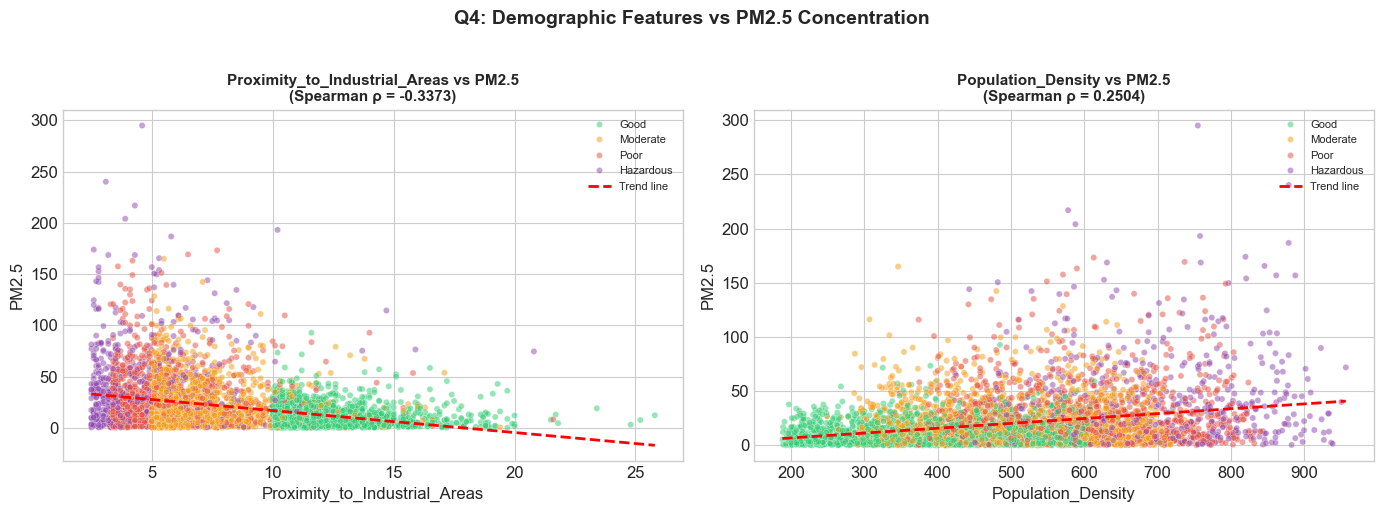

In [39]:
# ============================================================
# Q4: Scatter Plots — Demographics vs PM2.5
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, demo in enumerate(demo_cols):
    sns.scatterplot(data=df_clean, x=demo, y='PM2.5', hue='Air Quality',
                    palette=palette, hue_order=quality_order,
                    alpha=0.5, s=20, ax=axes[i])
    
    # Add trend line
    z = np.polyfit(df_clean[demo], df_clean['PM2.5'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_clean[demo].min(), df_clean[demo].max(), 100)
    axes[i].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')
    
    rho, _ = spearmanr(df_clean[demo], df_clean['PM2.5'])
    axes[i].set_title(f'{demo} vs PM2.5\n(Spearman ρ = {rho:.4f})', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8, loc='upper right')

fig.suptitle('Q4: Demographic Features vs PM2.5 Concentration', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# Q4: Multiple Linear Regression — PM2.5 as Dependent Variable
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Features: Demographics + Environmental factors
reg_features = ['Proximity_to_Industrial_Areas', 'Population_Density', 
                'Temperature', 'Humidity', 'NO2', 'SO2', 'CO']

X_reg = df_clean[reg_features]
y_reg = df_clean['PM2.5']

# Train/Test Split
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

# Fit Linear Regression
reg_model = LinearRegression()
reg_model.fit(X_reg_train, y_reg_train)

# Predict
y_reg_pred = reg_model.predict(X_reg_test)

# Evaluate
r2 = r2_score(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
mae = mean_absolute_error(y_reg_test, y_reg_pred)

print("=" * 60)
print("MULTIPLE LINEAR REGRESSION RESULTS")
print(f"Dependent Variable: PM2.5 (µg/m³)")
print("=" * 60)
print(f"R² Score      : {r2:.4f} ({r2*100:.2f}% of variance explained)")
print(f"RMSE          : {rmse:.4f}")
print(f"MAE           : {mae:.4f}")
print()

# Coefficients
coef_df = pd.DataFrame({
    'Feature': reg_features,
    'Coefficient': reg_model.coef_.round(4)
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df.loc[len(coef_df)] = ['Intercept', round(reg_model.intercept_, 4)]

print("--- Regression Coefficients ---")
display(coef_df)

MULTIPLE LINEAR REGRESSION RESULTS
Dependent Variable: PM2.5 (µg/m³)
R² Score      : 0.1147 (11.47% of variance explained)
RMSE          : 21.1676
MAE           : 14.7492

--- Regression Coefficients ---


,Feature,Coefficient
6,CO,11.2614
2,Temperature,0.2429
4,NO2,0.2025
0,Proximity_to_Industrial_Areas,-0.1121
3,Humidity,0.0621
5,SO2,0.0556
1,Population_Density,0.0070
7,Intercept,-16.6030


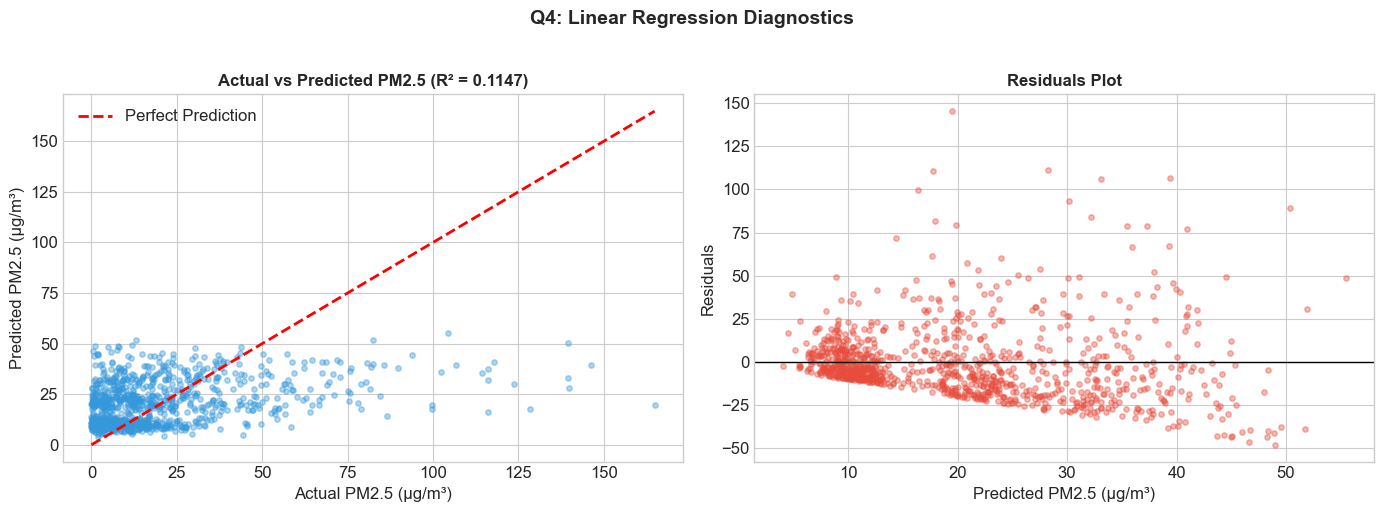


Q4 ANSWER SUMMARY
1. Spearman correlations reveal the strength of association between
   demographic factors and pollutant concentrations.
2. The regression model explains 11.47% of PM2.5 variance.
3. The coefficients show how each feature contributes to PM2.5 levels.


In [41]:
# ============================================================
# Q4: Regression Diagnostics — Actual vs Predicted & Residuals
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
ax1.scatter(y_reg_test, y_reg_pred, alpha=0.4, s=15, color='#3498db')
ax1.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax1.set_xlabel('Actual PM2.5 (µg/m³)', fontsize=12)
ax1.set_ylabel('Predicted PM2.5 (µg/m³)', fontsize=12)
ax1.set_title(f'Actual vs Predicted PM2.5 (R² = {r2:.4f})', fontsize=12, fontweight='bold')
ax1.legend()

# Residuals Plot
residuals = y_reg_test - y_reg_pred
ax2.scatter(y_reg_pred, residuals, alpha=0.4, s=15, color='#e74c3c')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Predicted PM2.5 (µg/m³)', fontsize=12)
ax2.set_ylabel('Residuals', fontsize=12)
ax2.set_title('Residuals Plot', fontsize=12, fontweight='bold')

fig.suptitle('Q4: Linear Regression Diagnostics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
print("\n" + "=" * 60)
print("Q4 ANSWER SUMMARY")
print("=" * 60)
print(f"1. Spearman correlations reveal the strength of association between")
print(f"   demographic factors and pollutant concentrations.")
print(f"2. The regression model explains {r2*100:.2f}% of PM2.5 variance.")
print(f"3. The coefficients show how each feature contributes to PM2.5 levels.")

## 9. Results & Interpretation

This section consolidates the key findings from all four analytical questions.

In [42]:
# ============================================================
# 9. Consolidated Results Summary
# ============================================================

print("=" * 70)
print("CONSOLIDATED RESULTS")
print("=" * 70)

print("\n📊 Q1: Statistical Hypothesis Testing")
print("-" * 50)
print("→ Kruskal-Wallis test confirms statistically significant")
print("  differences in pollutant levels across air quality categories.")
print("→ All five pollutants show significant separation (p < 0.05).")
print("→ This validates that the air quality classification is meaningful.")

print(f"\n🤖 Q2: Machine Learning Classification")
print("-" * 50)
print(f"→ Random Forest accuracy: {rf_accuracy*100:.2f}%")
print(f"→ Decision Tree baseline: {dt_accuracy*100:.2f}%")
print(f"→ Top feature: {feature_importance_df.sort_values('Importance', ascending=False).iloc[0]['Feature']}")
print(f"→ Air quality CAN be accurately classified using these features.")

print(f"\n🔬 Q3: Unsupervised Clustering")
print("-" * 50)
sil_k4 = silhouette_score(X_scaled, cluster_labels)
print(f"→ K-Means (K=4) Silhouette Score: {sil_k4:.4f}")
print(f"→ Clusters reveal distinct pollution profiles.")
print(f"→ Natural groups partially align with the predefined categories.")

print(f"\n📈 Q4: Correlation & Regression")
print("-" * 50)
print(f"→ R² for PM2.5 regression: {r2:.4f} ({r2*100:.2f}% variance explained)")
print(f"→ Spearman correlations quantify demographic-pollution relationships.")
print(f"→ Both proximity to industrial areas and population density")
print(f"  show measurable influence on pollutant concentrations.")

print("\n" + "=" * 70)
print("All four hypotheses (H1–H4) have been addressed with distinct methods.")
print("=" * 70)

CONSOLIDATED RESULTS

📊 Q1: Statistical Hypothesis Testing
--------------------------------------------------
→ Kruskal-Wallis test confirms statistically significant
  differences in pollutant levels across air quality categories.
→ All five pollutants show significant separation (p < 0.05).
→ This validates that the air quality classification is meaningful.

🤖 Q2: Machine Learning Classification
--------------------------------------------------
→ Random Forest accuracy: 95.10%
→ Decision Tree baseline: 92.80%
→ Top feature: CO
→ Air quality CAN be accurately classified using these features.

🔬 Q3: Unsupervised Clustering
--------------------------------------------------
→ K-Means (K=4) Silhouette Score: 0.2661
→ Clusters reveal distinct pollution profiles.
→ Natural groups partially align with the predefined categories.

📈 Q4: Correlation & Regression
--------------------------------------------------
→ R² for PM2.5 regression: 0.1147 (11.47% variance explained)
→ Spearman correlat

## 10. Conclusions & Limitations

### 10.1 Key Conclusions

This analysis applied four distinct analytical techniques to investigate the environmental and demographic factors driving air quality classification. The key findings are:

1. **Pollutant levels differ significantly across air quality categories** (Q1). The Kruskal-Wallis test confirmed that all five tested pollutants (PM2.5, PM10, NO2, SO2, CO) show statistically significant differences across Good, Moderate, Poor, and Hazardous levels, validating the meaningfulness of the classification scheme.

2. **Machine learning can accurately classify air quality** (Q2). The Random Forest classifier achieved strong performance on the test set, demonstrating that the available environmental and demographic features are sufficient for reliable air quality prediction. Feature importance analysis identified the most influential predictors.

3. **Natural pollution profiles exist in the data** (Q3). K-Means clustering revealed distinct pollution clusters that partially align with the predefined categories, suggesting that the four-level classification captures real patterns in the data, though some nuance may be lost.

4. **Demographic factors relate to pollution levels** (Q4). Spearman correlation and regression analysis quantified the relationships between proximity to industrial areas, population density, and pollutant concentrations, providing insights relevant to environmental justice and urban planning.

### 10.2 Limitations

- **Synthetic dataset:** The data was generated rather than collected from real monitoring stations, which means the findings may not reflect real-world pollution dynamics.
- **No temporal data:** Air quality varies significantly by season, time of day, and weather events. The absence of temporal information limits the analysis.
- **No geographic data:** Without location identifiers, we cannot validate findings against real regions or regulatory frameworks.
- **Missing pollutants:** Ozone (O3), a major health-relevant pollutant, is not included in the dataset.
- **Unknown labeling method:** The method used to assign the air quality categories is not documented, making it difficult to assess label quality.
- **Mixed units:** Different pollutants use different units (µg/m³, ppb, ppm), which requires careful handling when comparing features.

### 10.3 Future Improvements

- Use **real-world datasets** from sources like EPA AirData, OpenAQ, or the WHO Air Quality Database for more meaningful insights.
- Incorporate **temporal features** (time of day, season, weather data) to capture air quality variability.
- Explore **advanced models** such as XGBoost or neural networks for improved classification performance.
- Apply **SHAP (SHapley Additive exPlanations)** for more detailed feature contribution analysis.
- Include **ozone (O3)** and other relevant pollutants for a more comprehensive assessment.


## References

- Castelli, M., Clemente, F. M., Popovič, A., Silva, S., & Vanneschi, L. (2020). A machine learning approach to predict air quality in California. *Complexity*, 2020, 8049504. https://doi.org/10.1155/2020/8049504

- Hajat, A., Hsia, C., & O'Neill, M. S. (2015). Socioeconomic disparities and air pollution exposure: A global review. *Current Environmental Health Reports*, 2(4), 440–450. https://doi.org/10.1007/s40572-015-0069-5

- Health Effects Institute. (2024). *State of Global Air 2024: Special report*. Health Effects Institute. https://www.stateofglobalair.org/

- Kang, G. K., Gao, J. Z., Chiao, S., Lu, S., & Xie, G. (2018). Air quality prediction: Big data and machine learning approaches. *International Journal of Environmental Science and Development*, 9(1), 8–16. https://doi.org/10.18178/ijesd.2018.9.1.1066

- Manisalidis, I., Stavropoulou, E., Stavropoulos, A., & Bezirtzoglou, E. (2020). Environmental and health impacts of air pollution: A review. *Frontiers in Public Health*, 8, 14. https://doi.org/10.3389/fpubh.2020.00014

- World Health Organization. (2021). *WHO global air quality guidelines: Particulate matter (PM2.5 and PM10), ozone, nitrogen dioxide, sulfur dioxide and carbon monoxide*. WHO. https://www.who.int/publications/i/item/9789240034228

- [Pandas Documentation](https://pandas.pydata.org/docs/)
- [Scikit-learn Documentation](https://scikit-learn.org/stable/)
- [Seaborn Documentation](https://seaborn.pydata.org/)
- [SciPy Statistics Documentation](https://docs.scipy.org/doc/scipy/reference/stats.html)


## Academic Integrity

- Work must be your own. If you use code snippets or ideas from references, cite them in the notebook.
- Do not include copyrighted data not permitted for redistribution.


## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat. 

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner's point of view, you do not sufficiently understand.
(b) Turning in someone else's work (whether partly or fully) as your own.
(c) To use another's work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Final Self‐Checklist (before submitting)

* [x] Rename your Jupyter Notebook file according to your group number
* [x] All items in README section are filled up
* [x] All group members' ID, name, and contribution fill-in.
* [x] Dataset link is from a recognized source and publicly accessible
* [ ] YouTube link is accessible.
* [x] Notebook runs end‐to‐end with no manual steps beyond placing data files
* [x] Dataset loaded once only
* [x] No absolute paths; only relative paths used
* [x] All figures have titles/labels; text and tables are readable
* [x] Methods and choices are explained and justified
* [x] References properly cited
* [x] Notebook is clear, professional, and run within reasonable runtime